In [2]:
import os
import pandas as pd
import geopandas as gpd
from tabulate import tabulate
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# get the current directory 
data_dir = os.getcwd()

#set the data directory relative to the current directory
# data_dir = os.path.join(current_dir, 'data')

sectionA1_path = os.path.join(data_dir, 'August-October-2021-sectionA1-data.csv')
sectionA2_path = os.path.join(data_dir, 'August-October-2021-sectionA2-data.csv')
sectionA3_path = os.path.join(data_dir, 'August-October-2021-sectionA3-data.csv')
sectionA4_path = os.path.join(data_dir, 'August-October-2021-sectionA4-data.csv')
sectionC10_path = os.path.join(data_dir, 'August-October-2021-sectionC10-data.csv')
sectionC9_path = os.path.join(data_dir, 'August-October-2021-sectionC9-data.csv')

In [4]:
sectionA1_df = pd.read_csv(sectionA1_path)
sectionA2_df = pd.read_csv(sectionA2_path)
sectionA3_df = pd.read_csv(sectionA3_path)
sectionA4_df = pd.read_csv(sectionA4_path)
sectionC10_df = pd.read_csv(sectionC10_path)
sectionC9_df = pd.read_csv(sectionC9_path)

In [11]:
# # Explore CDR data
# print("Farm Data Summary:")
# print(sectionC9_df.head())
#print(sectionC9_df.info())

In [6]:

august2021 = len(sectionC10_df)
print(f"\nTotal DataStream over August 2021: {august2021}")


Total DataStream over August 2021: 18512


In [12]:
# Combine all dataframes into one
df_combined = pd.concat([sectionA1_df, sectionA2_df, sectionA3_df, sectionA4_df, sectionC10_df, sectionC9_df], ignore_index=True)


In [13]:
# Data Cleaning and Preprocessing
columns_to_keep = ['soil_moisture', 'soil_temperature', 'soil_electrocoductivity', 'battery_level', 'createdAt', 'sensor_id']
df_combined = df_combined[columns_to_keep]

In [14]:
# Convert 'createdAt' to datetime objects
df_combined['createdAt'] = pd.to_datetime(df_combined['createdAt'])

In [15]:
# --- Data Quality Checks ---

# 1. Check for Null Values
print("--- Null Value Check ---")
print(df_combined.isnull().sum())

--- Null Value Check ---
soil_moisture              0
soil_temperature           0
soil_electrocoductivity    0
battery_level              0
createdAt                  0
sensor_id                  0
dtype: int64


In [16]:
# 2. Check for Duplicates
print("\n--- Duplicate Check ---")
print(f"Number of duplicate rows: {df_combined.duplicated().sum()}")


--- Duplicate Check ---
Number of duplicate rows: 0


In [20]:
# 3. Check for Unrealistic Values (Negative Soil Moisture)
# print("\n--- Negative Soil Moisture Check ---")
# print(f"Number of rows with negative soil moisture: {len(df_combined[df_combined['soil_moisture'] < 0])}")

print("\n--- Negative Soil Moisture Check ---")
negative_soil_moisture = df_combined[df_combined['soil_moisture'] < 0]
print(f"Number of rows with negative soil moisture: {len(negative_soil_moisture)}")


--- Negative Soil Moisture Check ---
Number of rows with negative soil moisture: 16


In [21]:
# Print the rows with negative soil moisture
if not negative_soil_moisture.empty:
    print("\nRows with negative soil moisture:")
    print(negative_soil_moisture)


Rows with negative soil moisture:
       soil_moisture  soil_temperature  soil_electrocoductivity  \
39283            -18             22.30                      246   
39289            -19             22.30                      245   
40689            -36             22.60                      373   
40726            -42             22.30                      373   
40731            -49             22.30                      374   
40736            -54             22.30                      374   
41030            -54             23.16                      355   
73846            -68            369.20                        0   
73861            -68            368.80                        0   
73874            -68            367.80                        0   
73888            -68            367.40                        0   
73901            -68            366.20                        0   
73914            -68            367.40                        0   
73924            -68       

In [24]:
# Remove negative soil moisture values if necessary
df_combined = df_combined[df_combined['soil_moisture'] >= 0]


--- Sensor A101 Consistency Analysis ---
Number of spikes detected: 12
Spike timestamps:
157    2021-08-04 10:30:53
679    2021-08-12 16:31:33
2048   2021-09-07 11:01:26
2141   2021-09-08 11:51:50
2142   2021-09-08 12:01:35
2686   2021-09-18 06:39:35
2736   2021-09-19 00:56:27
3463   2021-10-03 14:54:28
3793   2021-10-12 10:16:00
4016   2021-10-17 06:41:15
4349   2021-10-23 16:00:48
4378   2021-10-24 05:56:34
Name: createdAt, dtype: datetime64[ns]


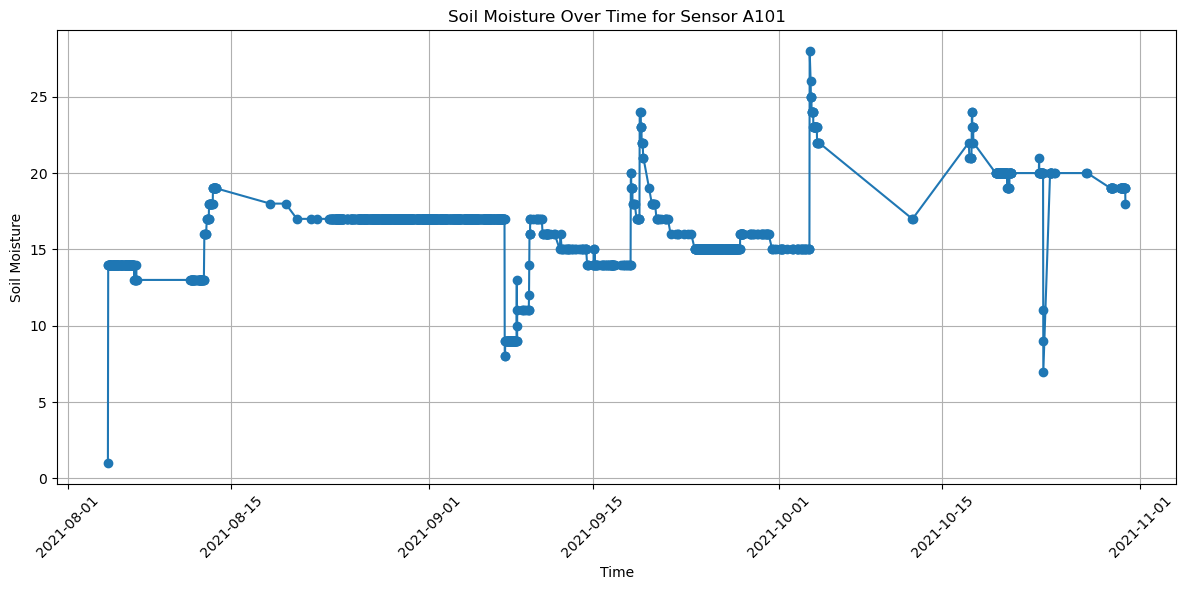


--- Sensor A102 Consistency Analysis ---
Number of spikes detected: 23
Spike timestamps:
2047   2021-09-07 10:49:25
2140   2021-09-08 11:40:55
2639   2021-09-17 11:18:46
2708   2021-09-18 13:36:53
2737   2021-09-19 01:15:42
2826   2021-09-20 14:15:49
2868   2021-09-21 10:02:04
2921   2021-09-22 10:21:53
2928   2021-09-22 13:55:00
2967   2021-09-23 09:11:36
2972   2021-09-23 12:14:47
2973   2021-09-23 12:45:18
3101   2021-09-26 10:44:37
3114   2021-09-26 14:48:20
3116   2021-09-26 15:18:34
3207   2021-09-28 14:57:23
3465   2021-10-03 15:49:43
3466   2021-10-03 16:19:59
3620   2021-10-06 13:30:17
3746   2021-10-09 08:38:29
3747   2021-10-09 09:08:50
3749   2021-10-11 11:47:05
4680   2021-10-30 14:13:55
Name: createdAt, dtype: datetime64[ns]


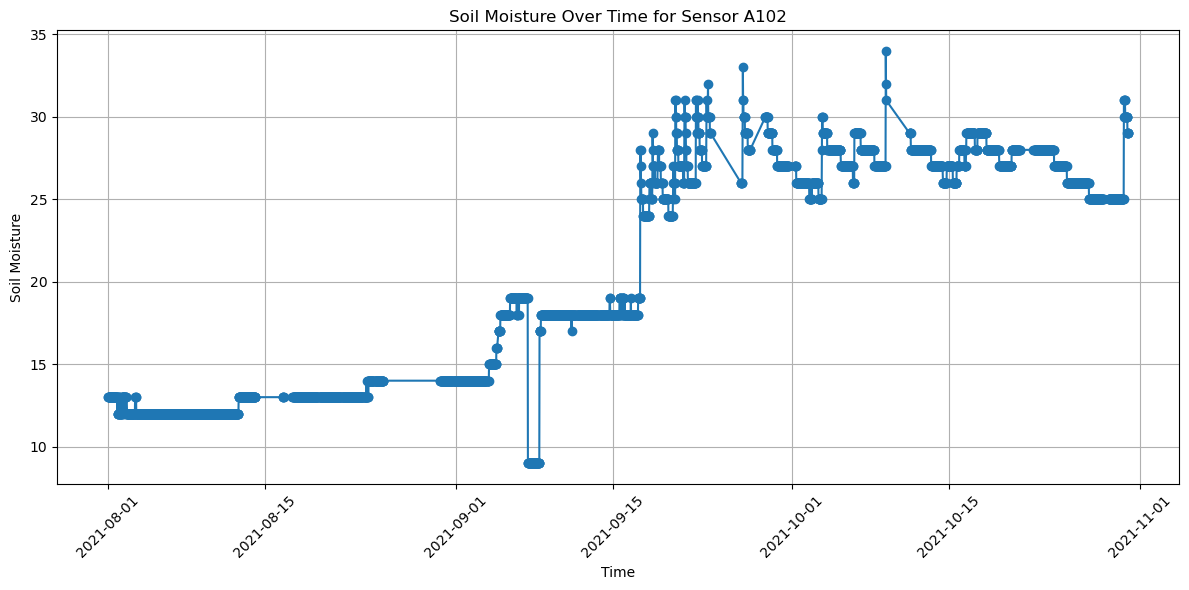


--- Sensor A201 Consistency Analysis ---
Number of spikes detected: 128
Spike timestamps:
5321    2021-08-05 23:25:25
5327    2021-08-06 00:26:11
5330    2021-08-06 00:56:33
6095    2021-08-12 12:04:06
6098    2021-08-12 12:34:25
                ...        
16017   2021-10-30 14:31:42
16023   2021-10-30 15:32:32
16026   2021-10-30 16:02:58
16029   2021-10-30 16:33:23
16066   2021-10-30 23:08:52
Name: createdAt, Length: 128, dtype: datetime64[ns]


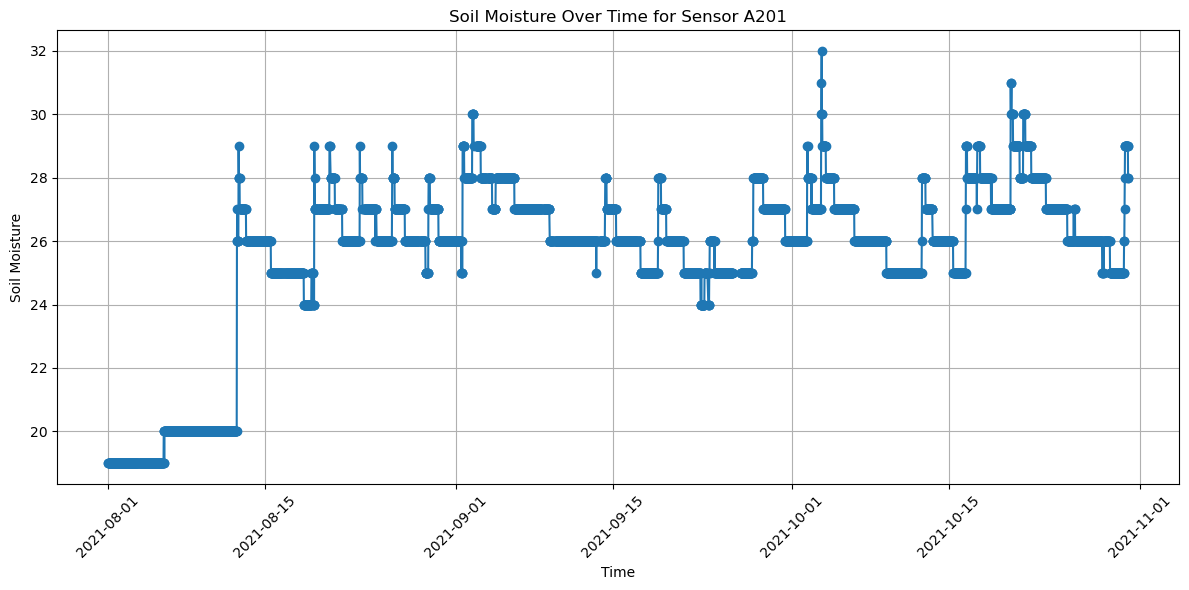


--- Sensor A202 Consistency Analysis ---
Number of spikes detected: 18
Spike timestamps:
5177    2021-08-04 21:10:39
5968    2021-08-11 13:57:10
6117    2021-08-12 15:47:39
6356    2021-08-14 10:19:21
7138    2021-08-20 09:01:01
7562    2021-08-23 15:21:28
8245    2021-08-30 15:02:40
8408    2021-08-31 21:57:38
8618    2021-09-02 11:28:41
11344   2021-09-23 09:38:07
11616   2021-09-26 13:21:12
11745   2021-09-27 12:44:55
12301   2021-10-01 12:43:28
12583   2021-10-03 14:43:13
13591   2021-10-12 09:54:51
14146   2021-10-16 12:05:17
14703   2021-10-20 12:07:29
16016   2021-10-30 14:12:01
Name: createdAt, dtype: datetime64[ns]


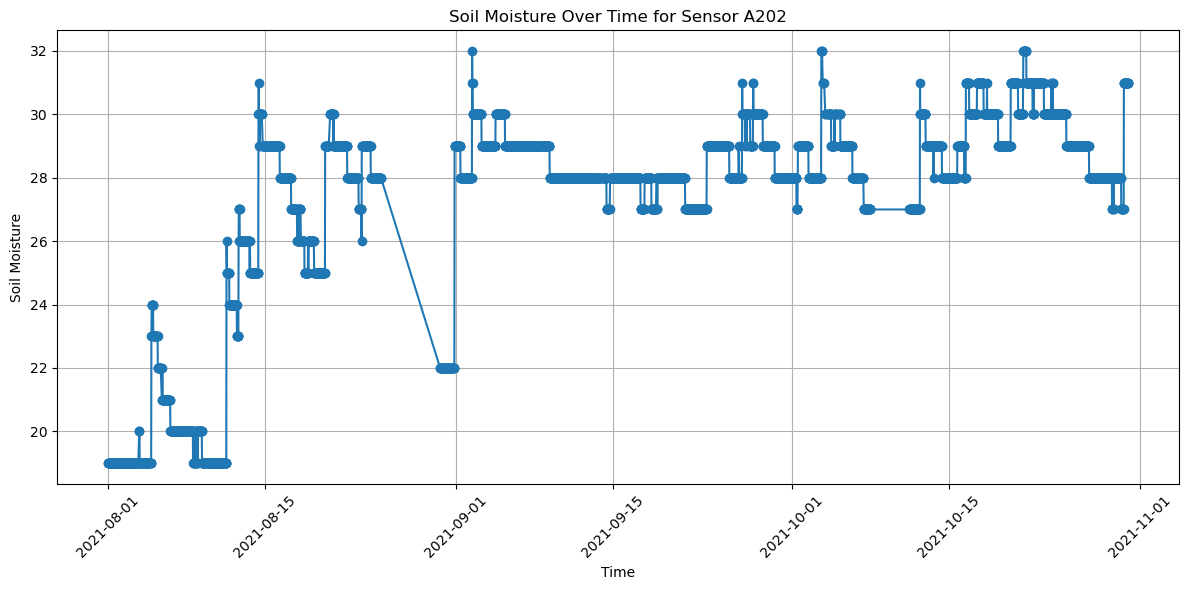


--- Sensor A203 Consistency Analysis ---
Number of spikes detected: 20
Spike timestamps:
5592    2021-08-07 23:30:18
5595    2021-08-08 00:00:09
5622    2021-08-08 04:28:17
5625    2021-08-08 04:58:09
5733    2021-08-09 01:36:02
5951    2021-08-11 11:07:21
10505   2021-09-17 05:36:44
10507   2021-09-17 06:08:21
11600   2021-09-26 10:24:02
12274   2021-10-01 07:52:37
12582   2021-10-03 14:37:55
13275   2021-10-09 11:49:42
13481   2021-10-11 14:50:44
14040   2021-10-15 17:52:25
14145   2021-10-16 11:59:36
14283   2021-10-17 12:08:48
14702   2021-10-20 11:59:16
14856   2021-10-21 14:42:20
16015   2021-10-30 14:11:55
16028   2021-10-30 16:14:36
Name: createdAt, dtype: datetime64[ns]


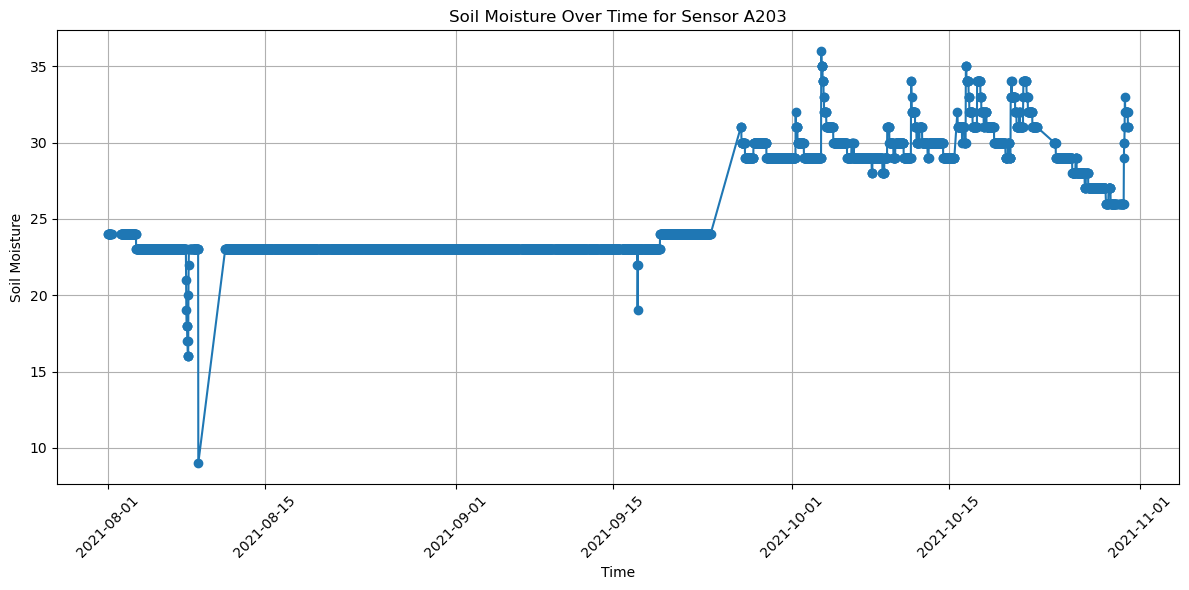


--- Sensor A301 Consistency Analysis ---
Number of spikes detected: 23
Spike timestamps:
16138   2021-08-01 19:01:53
16888   2021-08-10 08:32:03
17012   2021-08-11 13:26:09
17149   2021-08-12 15:53:26
17415   2021-08-14 15:06:34
18138   2021-08-20 11:35:01
18141   2021-08-20 12:05:12
21435   2021-09-17 12:11:42
21604   2021-09-19 00:43:37
22029   2021-09-22 07:50:36
22034   2021-09-22 08:51:05
23126   2021-10-02 15:03:33
23141   2021-10-02 17:35:46
23221   2021-10-03 11:54:57
23233   2021-10-03 14:27:14
24001   2021-10-11 08:00:03
24003   2021-10-11 08:30:25
24193   2021-10-13 08:29:54
24402   2021-10-15 15:19:40
24493   2021-10-17 11:54:03
24894   2021-10-20 12:08:03
25013   2021-10-21 14:27:56
26029   2021-10-30 13:46:14
Name: createdAt, dtype: datetime64[ns]


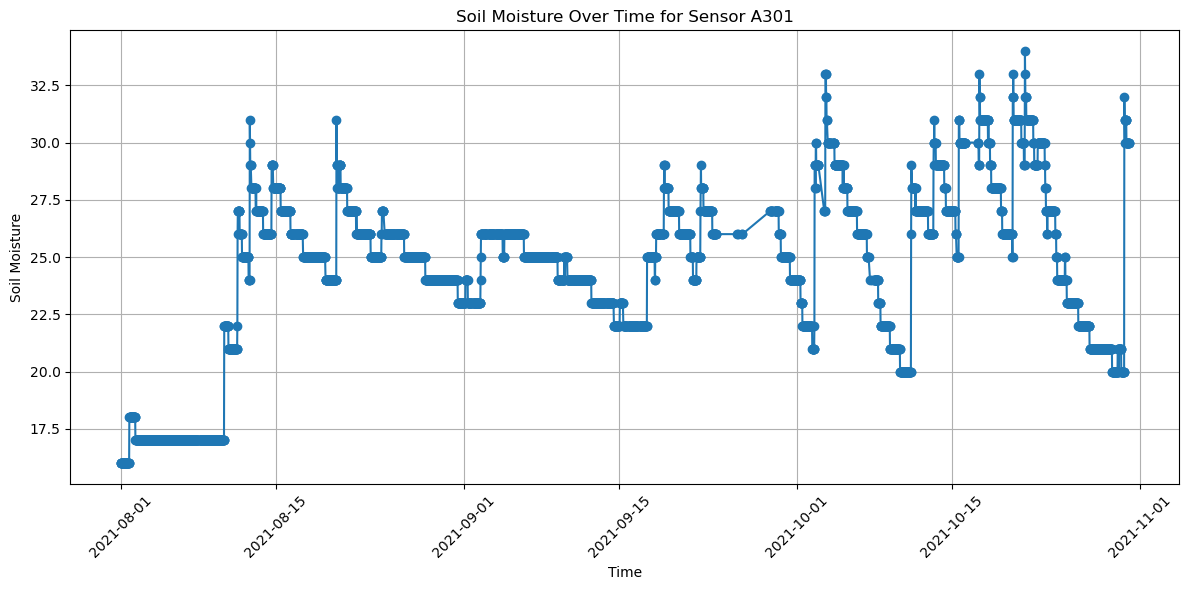


--- Sensor A302 Consistency Analysis ---
Number of spikes detected: 71
Spike timestamps:
16378   2021-08-05 01:59:31
16839   2021-08-09 19:28:14
16845   2021-08-09 20:58:53
16847   2021-08-09 21:29:06
16851   2021-08-09 22:29:33
                ...        
25646   2021-10-27 03:11:34
25652   2021-10-27 04:12:02
25869   2021-10-29 10:28:54
26034   2021-10-30 14:40:37
26039   2021-10-30 15:40:53
Name: createdAt, Length: 71, dtype: datetime64[ns]


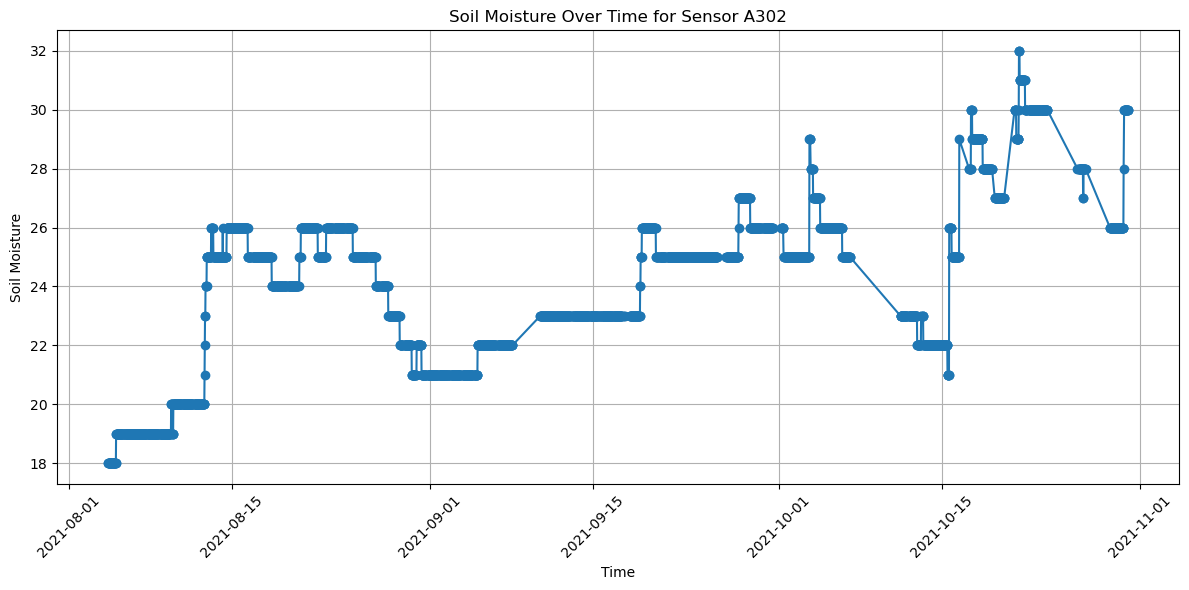


--- Sensor A303 Consistency Analysis ---
Number of spikes detected: 28
Spike timestamps:
16098   2021-08-01 07:24:05
16645   2021-08-07 19:35:37
16808   2021-08-09 11:58:20
16819   2021-08-09 14:30:13
16913   2021-08-10 14:19:56
16975   2021-08-11 06:02:02
17126   2021-08-12 10:37:40
18166   2021-08-20 19:12:38
19653   2021-09-02 11:41:48
19656   2021-09-02 12:12:03
19892   2021-09-04 13:42:39
21337   2021-09-16 16:53:13
22534   2021-09-27 14:03:20
23232   2021-10-03 14:19:11
23240   2021-10-03 15:50:18
23243   2021-10-03 16:20:41
23603   2021-10-06 12:40:18
23707   2021-10-08 00:00:12
24042   2021-10-11 16:25:14
24470   2021-10-17 07:52:00
24494   2021-10-17 11:58:00
24497   2021-10-17 12:28:16
24895   2021-10-20 12:09:43
24901   2021-10-20 13:40:33
25012   2021-10-21 14:26:29
25015   2021-10-21 14:56:44
26033   2021-10-30 14:18:29
26053   2021-10-30 18:21:53
Name: createdAt, dtype: datetime64[ns]


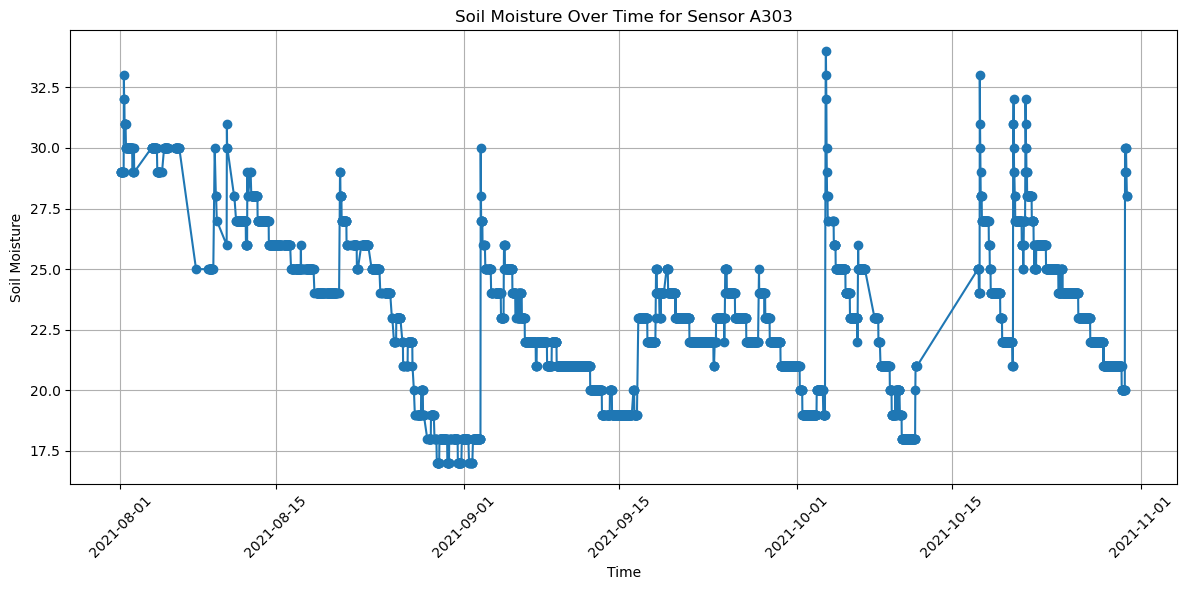


--- Sensor A401 Consistency Analysis ---
Number of spikes detected: 167
Spike timestamps:
27891   2021-08-08 18:16:57
27895   2021-08-08 18:47:10
27909   2021-08-08 20:17:51
27973   2021-08-09 02:50:51
28213   2021-08-10 05:40:58
                ...        
45468   2021-10-30 13:41:23
45472   2021-10-30 14:11:51
45477   2021-10-30 15:12:42
45485   2021-10-30 16:44:06
45490   2021-10-30 17:44:58
Name: createdAt, Length: 167, dtype: datetime64[ns]


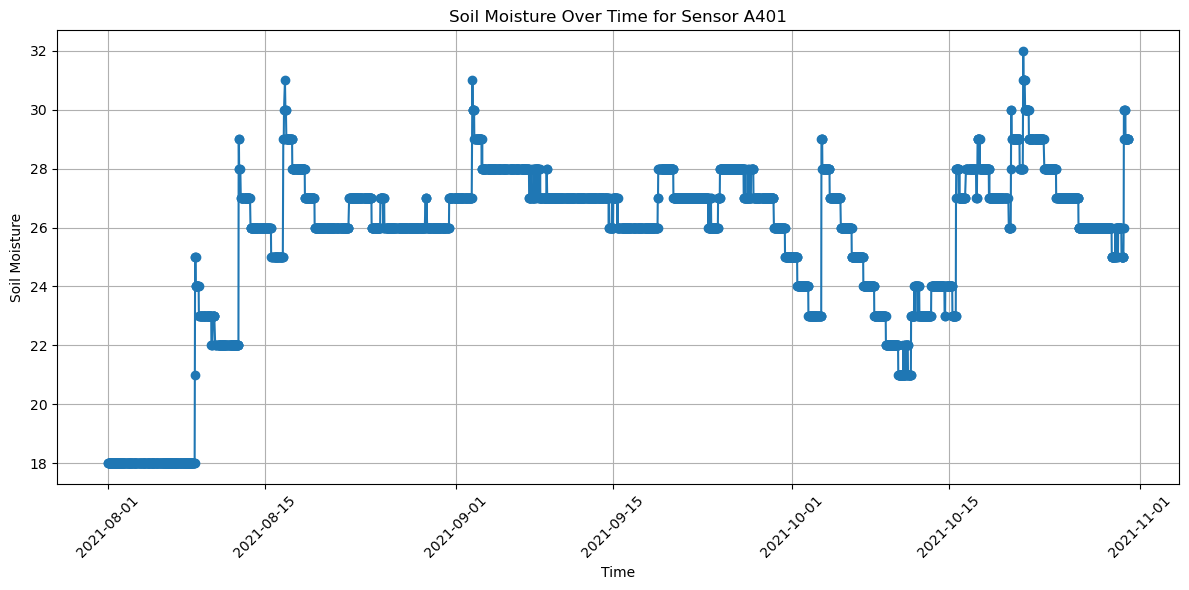


--- Sensor A402 Consistency Analysis ---
Number of spikes detected: 14
Spike timestamps:
28719   2021-08-12 15:55:30
39018   2021-09-28 03:15:29
39021   2021-09-28 03:45:38
39031   2021-09-28 04:45:59
39223   2021-09-28 22:57:31
39229   2021-09-28 23:27:47
39254   2021-09-29 01:28:42
39260   2021-09-29 01:58:57
39294   2021-09-29 05:00:44
39733   2021-09-30 19:02:41
39739   2021-09-30 19:32:58
39744   2021-09-30 20:03:13
42643   2021-10-15 14:59:36
43803   2021-10-22 11:48:37
Name: createdAt, dtype: datetime64[ns]


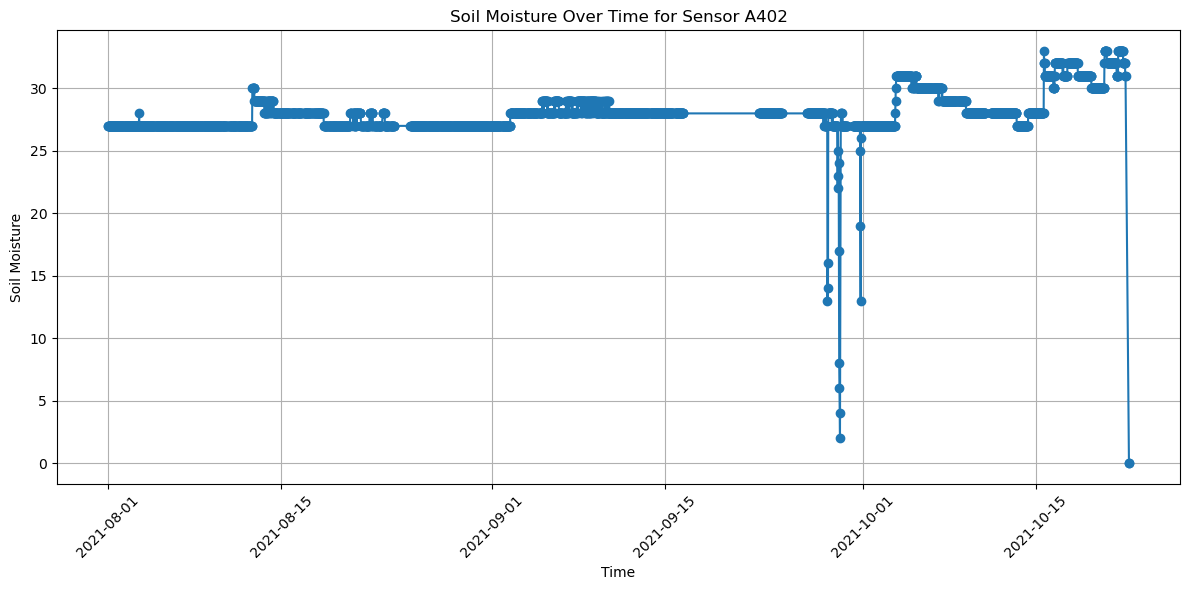


--- Sensor A403 Consistency Analysis ---
Number of spikes detected: 8
Spike timestamps:
27191   2021-08-05 23:30:06
27274   2021-08-06 06:38:34
28718   2021-08-12 15:45:59
37207   2021-09-19 00:34:51
39982   2021-10-01 15:49:24
39988   2021-10-01 16:23:41
39993   2021-10-01 16:54:07
43169   2021-10-19 08:24:55
Name: createdAt, dtype: datetime64[ns]


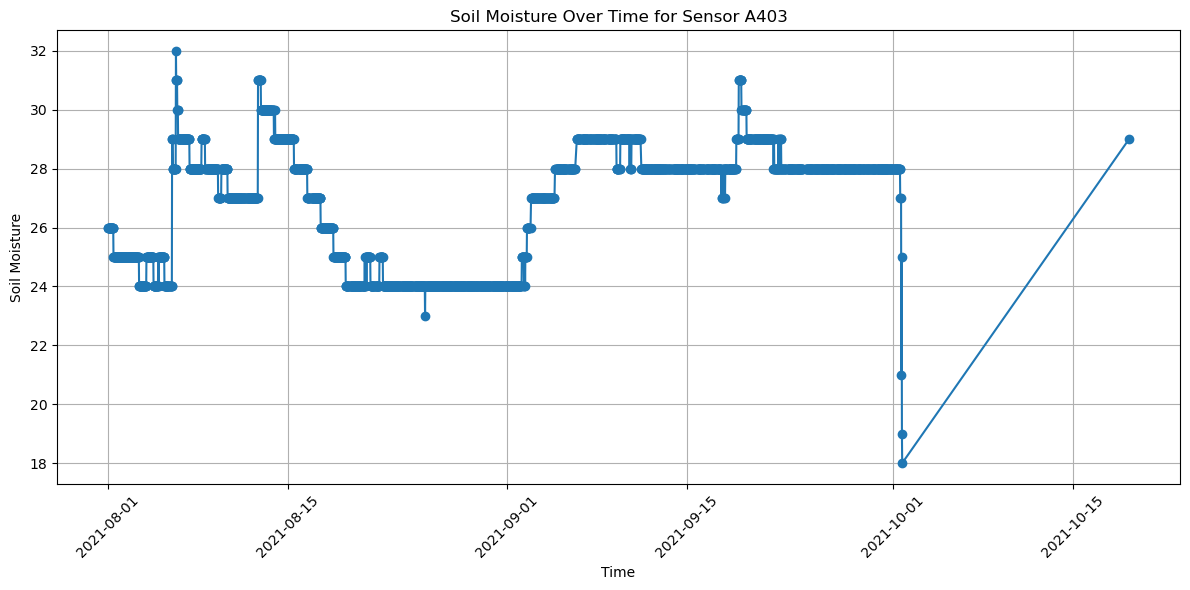


--- Sensor A404 Consistency Analysis ---
Number of spikes detected: 100
Spike timestamps:
26406   2021-08-02 10:18:54
27088   2021-08-05 13:38:08
27155   2021-08-05 20:17:04
27309   2021-08-06 09:54:19
27419   2021-08-06 20:01:07
                ...        
45346   2021-10-29 20:40:56
45350   2021-10-29 21:11:20
45437   2021-10-30 08:55:55
45471   2021-10-30 14:01:31
45474   2021-10-30 14:31:57
Name: createdAt, Length: 100, dtype: datetime64[ns]


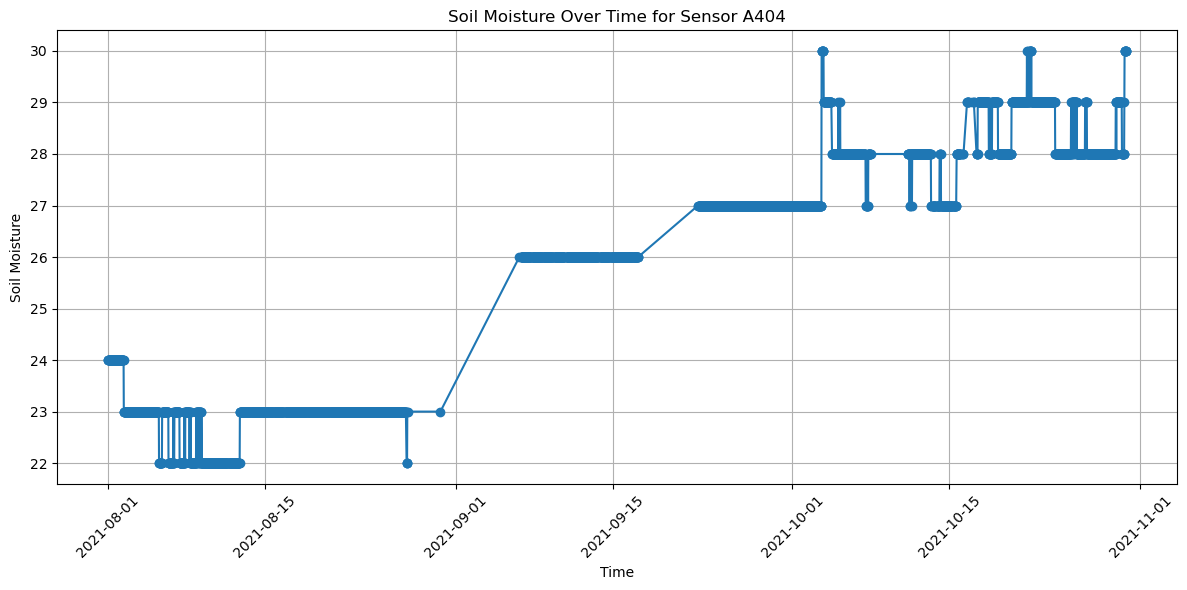


--- Sensor A405 Consistency Analysis ---
Number of spikes detected: 13
Spike timestamps:
28722   2021-08-12 16:01:23
33335   2021-08-31 20:24:18
34468   2021-09-06 15:44:49
34473   2021-09-06 16:15:40
34649   2021-09-07 10:29:05
41687   2021-10-11 07:14:26
42739   2021-10-16 04:15:20
43164   2021-10-19 07:50:55
43187   2021-10-19 11:16:46
43397   2021-10-20 12:01:55
44649   2021-10-26 11:24:07
45301   2021-10-29 14:34:58
45469   2021-10-30 13:58:26
Name: createdAt, dtype: datetime64[ns]


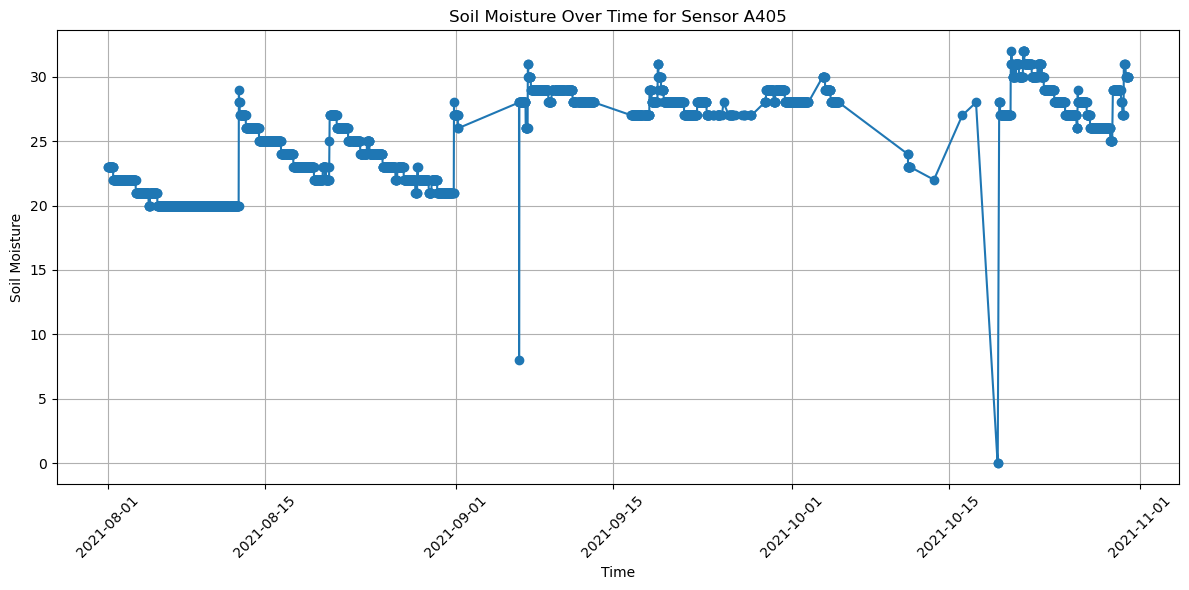


--- Sensor A406 Consistency Analysis ---
Number of spikes detected: 22
Spike timestamps:
29715   2021-08-16 18:50:45
31481   2021-08-23 15:42:44
33665   2021-09-02 11:35:27
36519   2021-09-14 21:22:28
36524   2021-09-14 21:52:31
36530   2021-09-14 22:22:44
37029   2021-09-17 16:26:14
37210   2021-09-19 00:51:43
37688   2021-09-21 17:21:50
38331   2021-09-24 12:22:33
40394   2021-10-03 14:38:53
41256   2021-10-07 19:20:59
41689   2021-10-11 07:32:41
42933   2021-10-17 18:59:08
43403   2021-10-20 12:51:04
43407   2021-10-20 13:21:23
43605   2021-10-21 14:03:35
43743   2021-10-22 04:44:52
44877   2021-10-27 12:50:11
44889   2021-10-27 14:21:39
45449   2021-10-30 10:56:25
45494   2021-10-30 18:33:33
Name: createdAt, dtype: datetime64[ns]


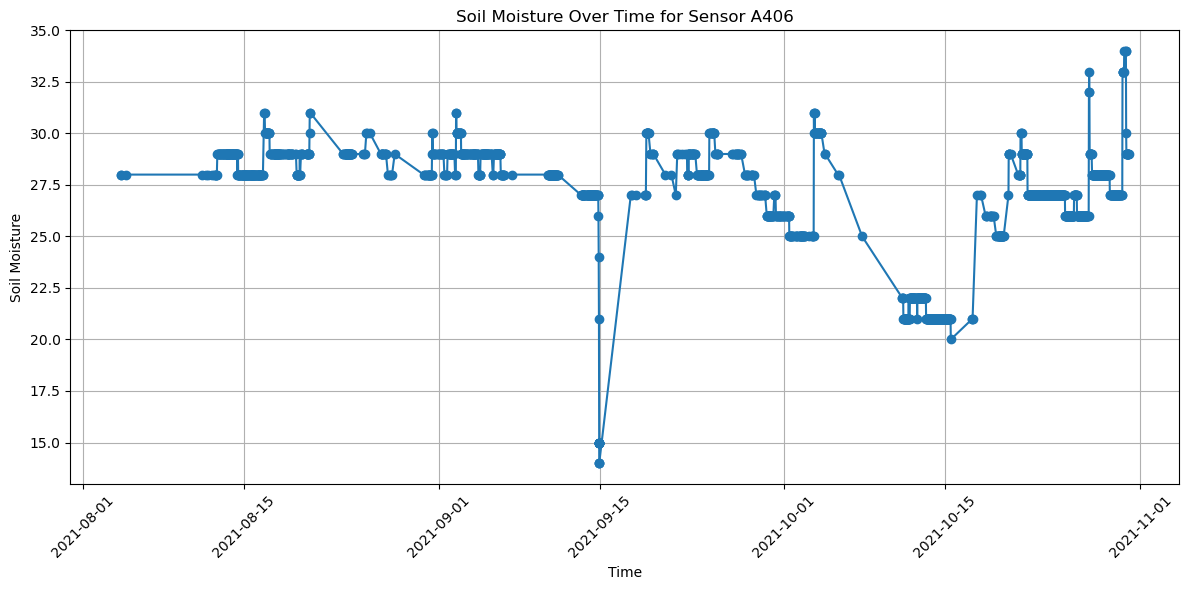


--- Sensor A407 Consistency Analysis ---
Number of spikes detected: 15
Spike timestamps:
26816   2021-08-04 08:05:05
29686   2021-08-16 14:28:45
33664   2021-09-02 11:12:23
37219   2021-09-19 01:55:05
38632   2021-09-26 12:14:54
40388   2021-10-03 14:27:06
42644   2021-10-15 15:20:41
42783   2021-10-16 12:04:36
43478   2021-10-20 22:14:33
43632   2021-10-21 16:59:00
43794   2021-10-22 10:56:33
43802   2021-10-22 11:35:50
45061   2021-10-28 09:40:37
45064   2021-10-28 10:11:04
45077   2021-10-28 11:42:19
Name: createdAt, dtype: datetime64[ns]


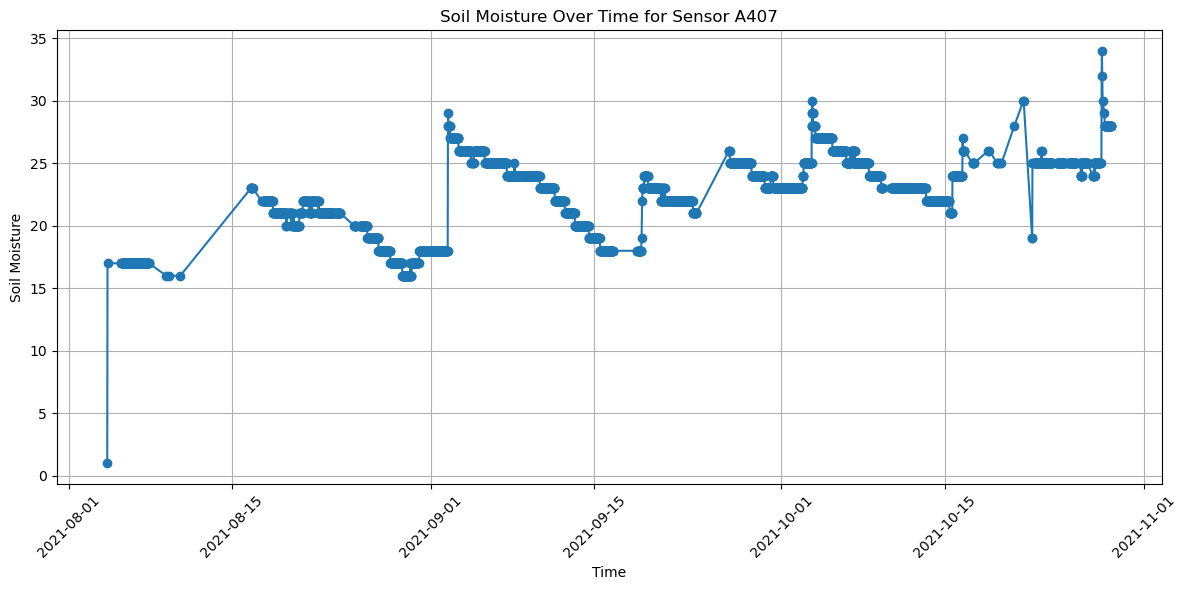


--- Sensor C1001 Consistency Analysis ---
Number of spikes detected: 10
Spike timestamps:
46112   2021-08-04 00:03:20
46457   2021-08-05 13:04:41
49491   2021-08-21 01:35:56
49496   2021-08-21 02:06:13
50408   2021-08-26 00:28:25
51482   2021-09-01 15:46:14
61845   2021-10-20 12:22:31
62115   2021-10-21 14:08:25
63957   2021-10-30 13:56:58
63965   2021-10-30 14:57:55
Name: createdAt, dtype: datetime64[ns]


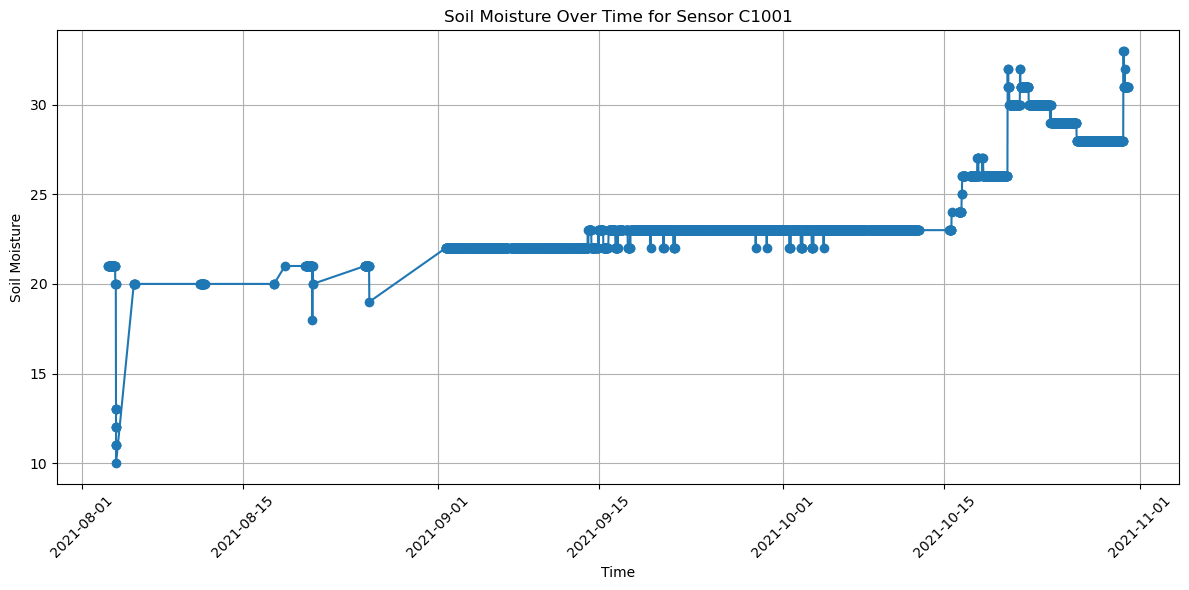


--- Sensor C1002 Consistency Analysis ---
Number of spikes detected: 72
Spike timestamps:
51649   2021-09-02 10:12:51
51659   2021-09-02 11:13:40
51664   2021-09-02 11:44:02
51668   2021-09-02 12:14:25
51680   2021-09-02 13:45:36
                ...        
63915   2021-10-30 08:25:49
63962   2021-10-30 14:28:54
63966   2021-10-30 14:59:00
63993   2021-10-30 18:29:39
64021   2021-10-30 22:00:17
Name: createdAt, Length: 72, dtype: datetime64[ns]


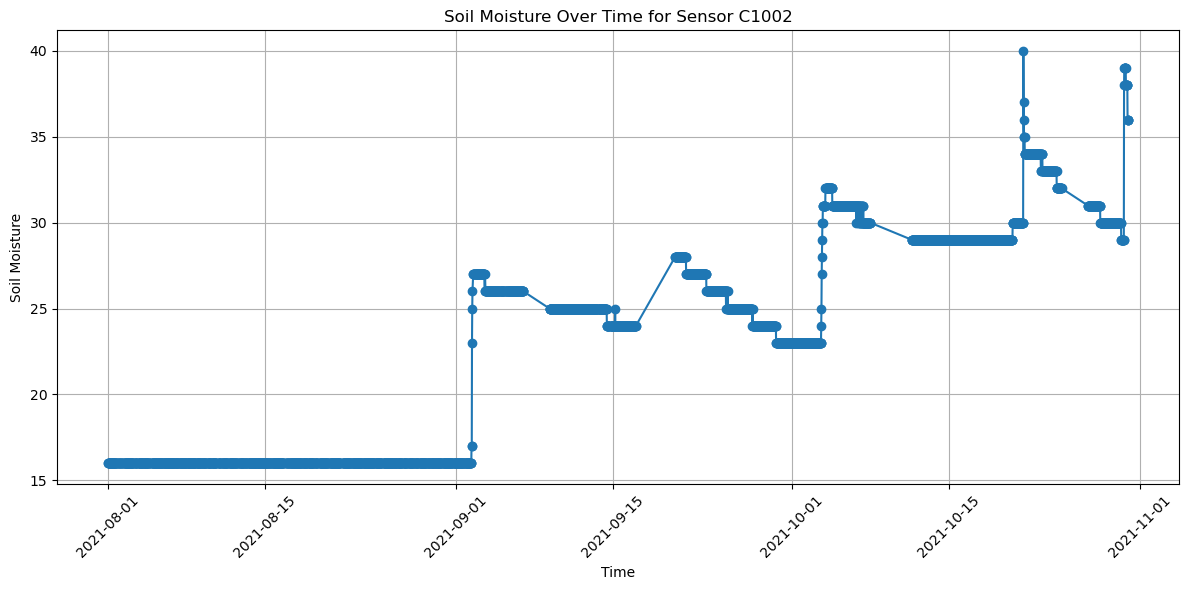


--- Sensor C1003 Consistency Analysis ---
Number of spikes detected: 150
Spike timestamps:
45537   2021-08-01 01:42:45
47243   2021-08-09 00:25:11
48746   2021-08-16 05:42:52
48750   2021-08-16 06:13:20
48754   2021-08-16 06:43:50
                ...        
61844   2021-10-20 12:14:48
61849   2021-10-20 12:45:14
63256   2021-10-27 08:39:29
63959   2021-10-30 14:12:11
64011   2021-10-30 20:43:23
Name: createdAt, Length: 150, dtype: datetime64[ns]


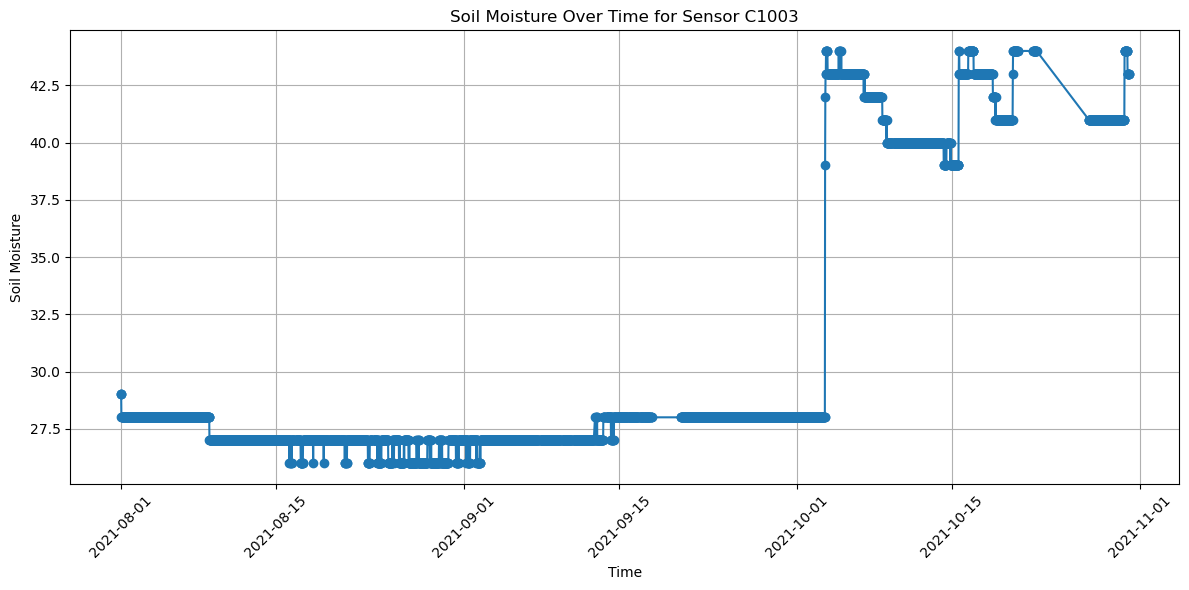


--- Sensor C1004 Consistency Analysis ---
Number of spikes detected: 82
Spike timestamps:
46617   2021-08-06 05:46:11
46699   2021-08-06 14:22:08
46781   2021-08-06 23:26:44
46786   2021-08-06 23:56:56
46791   2021-08-07 00:27:06
                ...        
63004   2021-10-25 13:17:41
63026   2021-10-25 17:20:33
63029   2021-10-25 17:50:51
63157   2021-10-26 15:36:56
63960   2021-10-30 14:14:31
Name: createdAt, Length: 82, dtype: datetime64[ns]


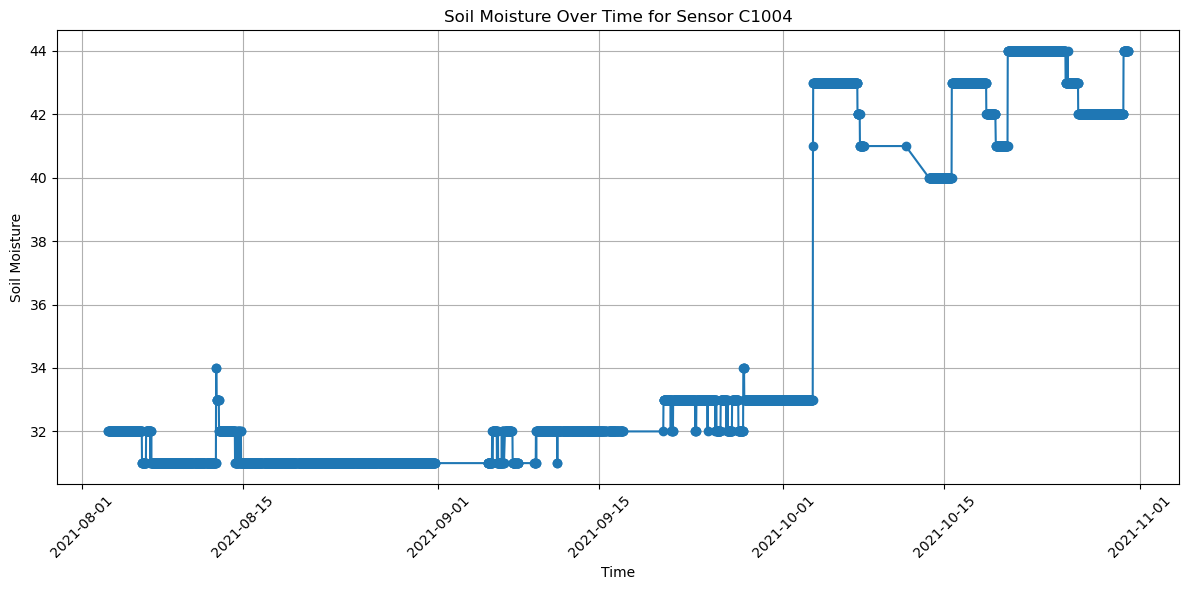


--- Sensor C1005 Consistency Analysis ---
Number of spikes detected: 12
Spike timestamps:
51658   2021-09-02 11:12:22
52074   2021-09-04 13:27:04
53081   2021-09-10 09:13:04
53083   2021-09-10 09:25:42
54723   2021-09-20 14:12:08
55671   2021-09-24 10:15:53
56109   2021-09-26 06:59:10
56456   2021-09-27 12:45:06
57226   2021-09-30 09:55:50
60584   2021-10-15 15:35:59
60792   2021-10-16 11:54:10
61847   2021-10-20 12:34:06
Name: createdAt, dtype: datetime64[ns]


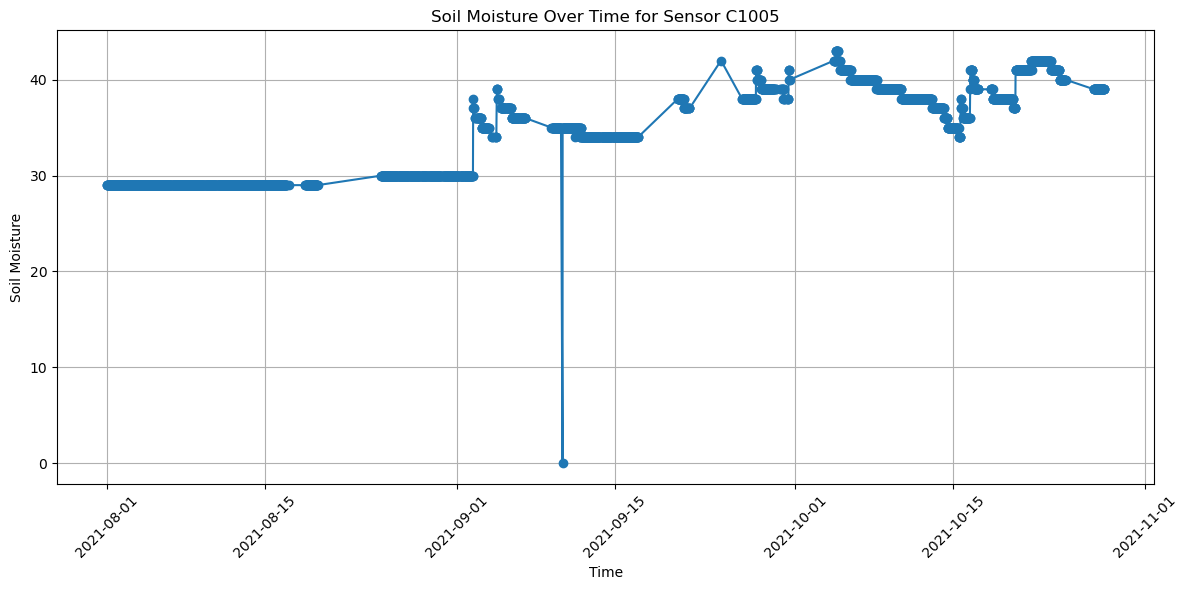


--- Sensor C1006 Consistency Analysis ---
Number of spikes detected: 16
Spike timestamps:
48333   2021-08-13 23:50:01
48371   2021-08-14 03:49:43
48373   2021-08-14 03:50:16
48374   2021-08-14 03:50:33
48949   2021-08-17 16:20:27
48971   2021-08-17 18:53:29
49095   2021-08-18 16:20:29
50425   2021-08-26 02:15:45
51479   2021-09-01 15:20:26
51646   2021-09-02 10:03:54
51651   2021-09-02 10:34:14
51656   2021-09-02 11:04:35
52071   2021-09-04 13:10:49
52943   2021-09-09 17:20:24
57982   2021-10-03 14:40:13
59688   2021-10-11 16:34:19
Name: createdAt, dtype: datetime64[ns]


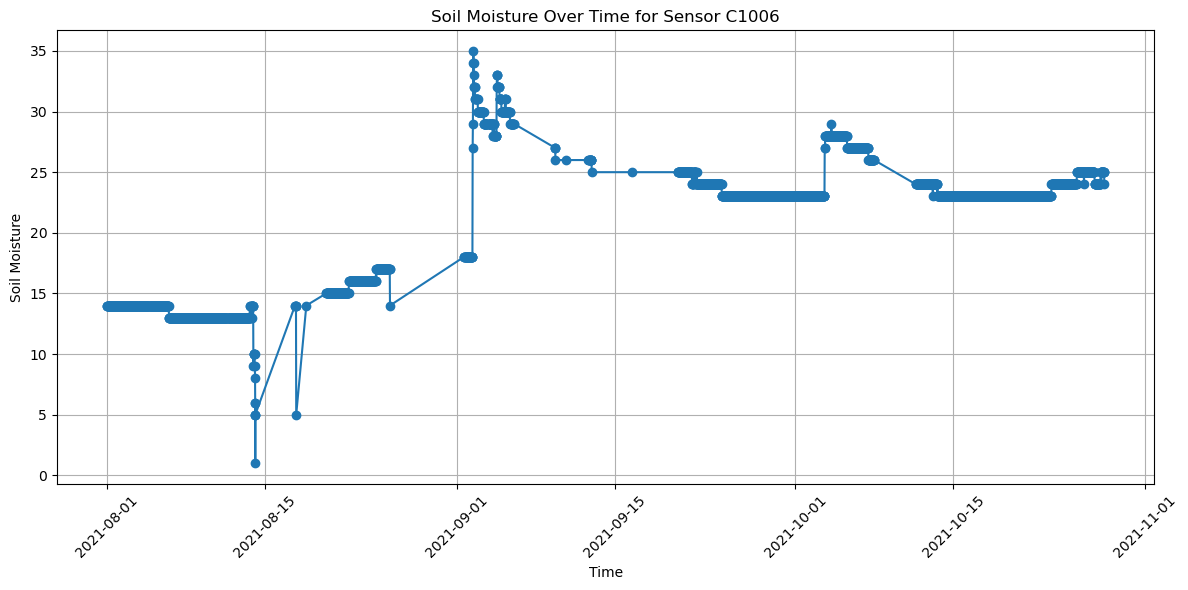


--- Sensor C901 Consistency Analysis ---
Number of spikes detected: 23
Spike timestamps:
66152    2021-08-05 09:04:07
66163    2021-08-05 09:29:07
66268    2021-08-05 13:50:46
66273    2021-08-05 14:09:26
66348    2021-08-05 17:13:06
69129    2021-08-11 14:40:36
69834    2021-08-13 01:27:20
72024    2021-08-17 17:06:35
72585    2021-08-18 16:47:34
95763    2021-10-03 14:15:13
100650   2021-10-14 03:36:57
100691   2021-10-14 05:24:37
100755   2021-10-14 05:46:23
100756   2021-10-14 05:46:42
101732   2021-10-15 21:40:19
101946   2021-10-16 06:10:40
102396   2021-10-16 23:53:57
102533   2021-10-17 06:18:05
104489   2021-10-20 13:13:58
104502   2021-10-20 13:44:16
104914   2021-10-21 14:01:07
104921   2021-10-21 14:31:26
105155   2021-10-22 07:11:24
Name: createdAt, dtype: datetime64[ns]


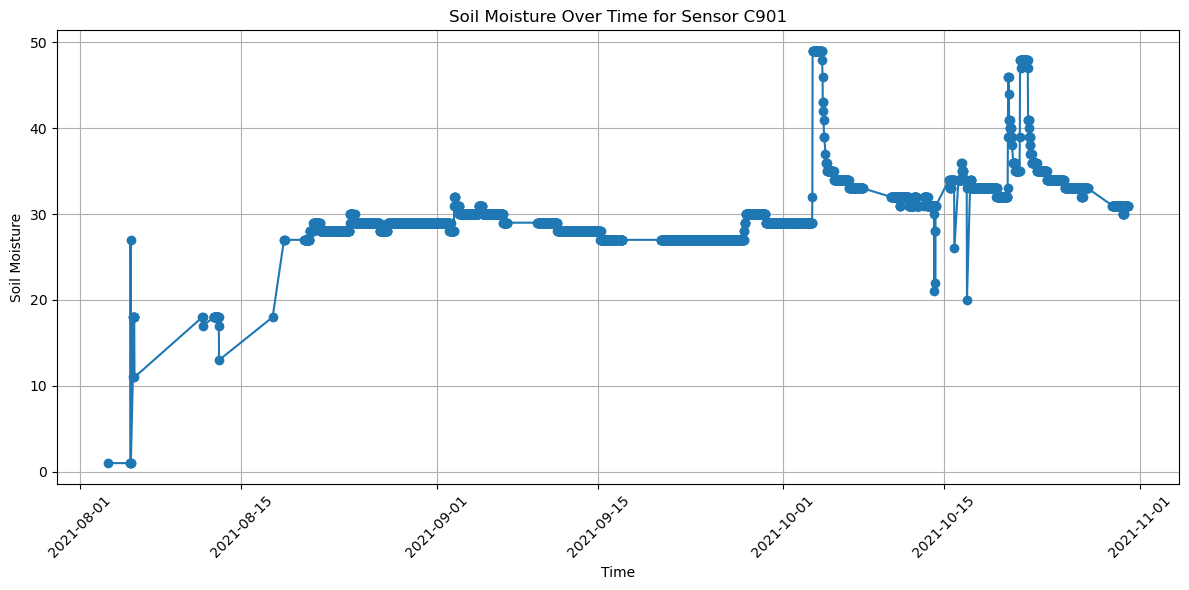


--- Sensor C902 Consistency Analysis ---
Number of spikes detected: 124
Spike timestamps:
69724    2021-08-12 20:55:20
69796    2021-08-12 23:56:53
69958    2021-08-13 06:59:13
70323    2021-08-14 02:12:17
70405    2021-08-14 06:14:16
                 ...        
109596   2021-10-30 12:48:14
109609   2021-10-30 13:18:44
109636   2021-10-30 14:19:32
109650   2021-10-30 14:49:54
109675   2021-10-30 15:50:40
Name: createdAt, Length: 124, dtype: datetime64[ns]


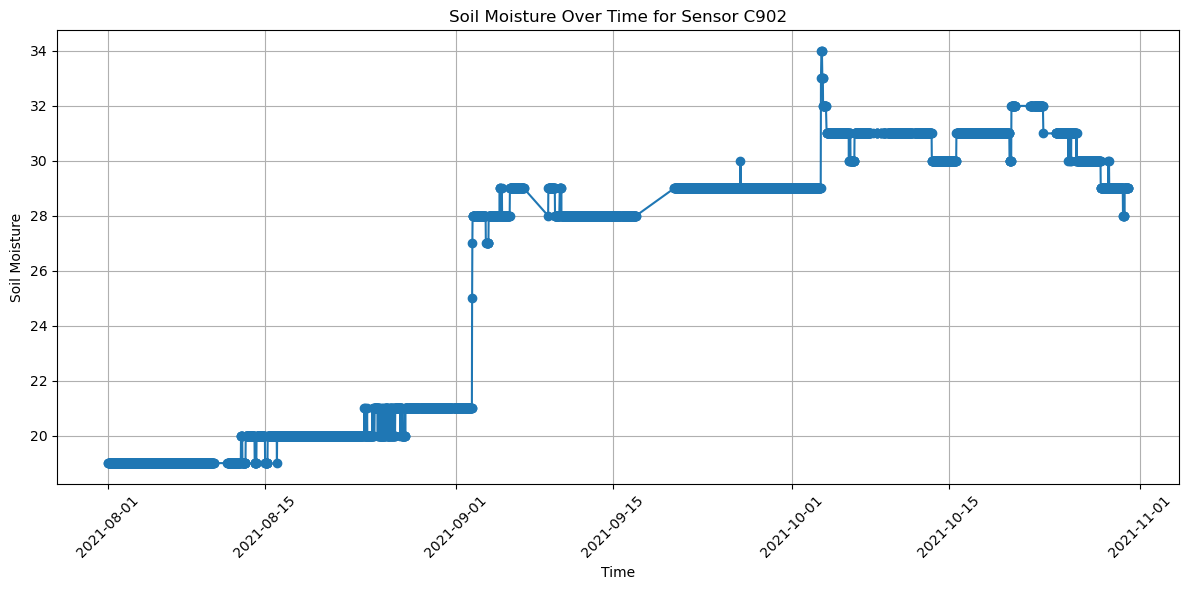


--- Sensor C903 Consistency Analysis ---
Number of spikes detected: 21
Spike timestamps:
66320    2021-08-05 15:55:32
66712    2021-08-06 10:12:11
67764    2021-08-08 11:30:49
67833    2021-08-08 14:53:55
68718    2021-08-10 14:00:08
69450    2021-08-12 07:36:49
69613    2021-08-12 15:45:35
71021    2021-08-15 13:27:08
73948    2021-08-21 06:18:34
74708    2021-08-22 12:40:31
76822    2021-08-26 09:11:02
80059    2021-09-01 09:45:51
80650    2021-09-02 10:34:41
80661    2021-09-02 11:04:59
81637    2021-09-04 13:09:39
96185    2021-10-04 10:03:08
96249    2021-10-04 12:47:04
104469   2021-10-20 12:28:35
104493   2021-10-20 13:29:17
104919   2021-10-21 14:22:32
109681   2021-10-30 16:06:13
Name: createdAt, dtype: datetime64[ns]


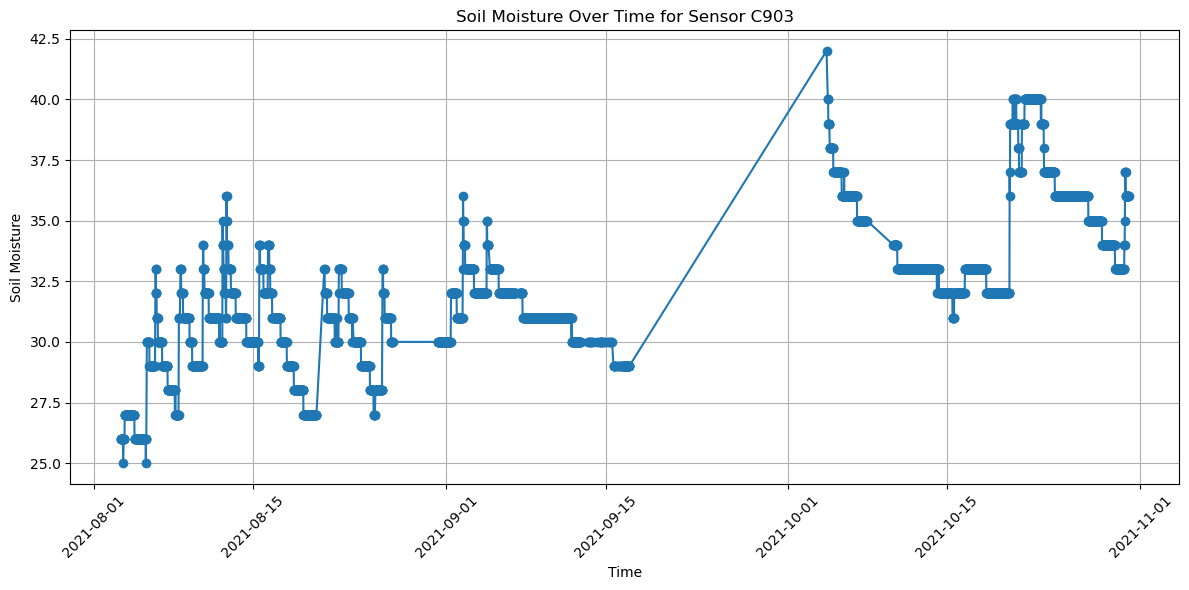


--- Sensor C904 Consistency Analysis ---
Number of spikes detected: 108
Spike timestamps:
68951    2021-08-11 04:44:12
69596    2021-08-12 15:06:57
69609    2021-08-12 15:37:18
69643    2021-08-12 17:08:08
69764    2021-08-12 22:41:06
                 ...        
107031   2021-10-26 04:24:07
107210   2021-10-26 12:28:21
107808   2021-10-27 13:46:49
108863   2021-10-29 08:48:12
109537   2021-10-30 10:40:38
Name: createdAt, Length: 108, dtype: datetime64[ns]


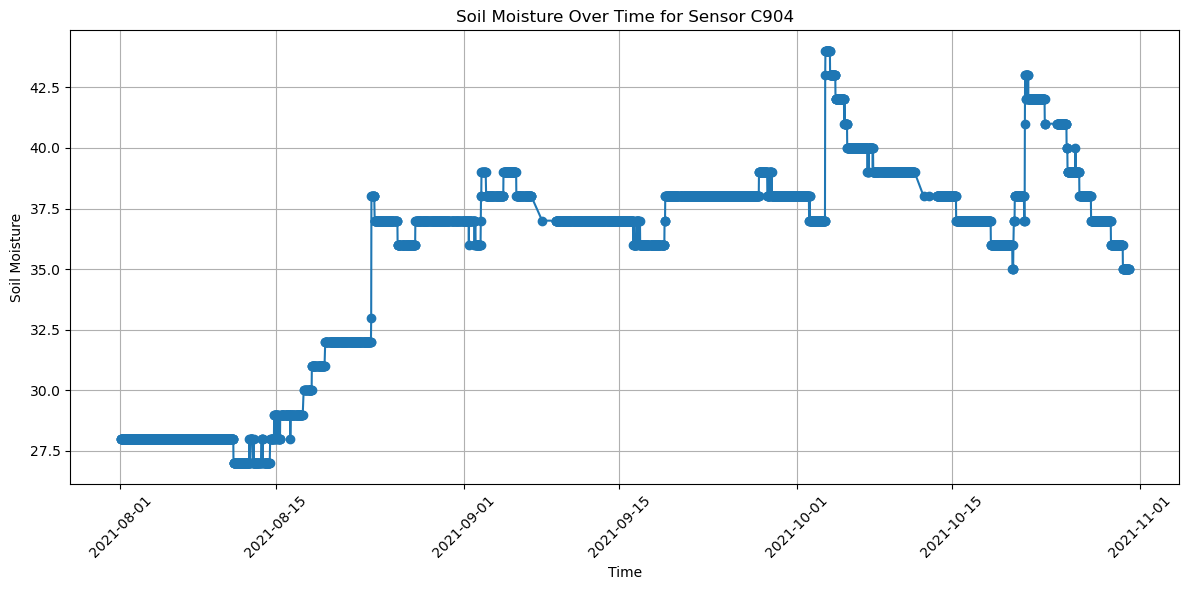


--- Sensor C905 Consistency Analysis ---
Number of spikes detected: 110
Spike timestamps:
72069    2021-08-17 19:21:52
72082    2021-08-17 19:52:09
75727    2021-08-24 09:29:33
75750    2021-08-24 10:30:37
77603    2021-08-27 18:19:55
                 ...        
109278   2021-10-30 00:39:00
109305   2021-10-30 01:39:15
109318   2021-10-30 02:09:24
109356   2021-10-30 03:39:46
109634   2021-10-30 14:15:56
Name: createdAt, Length: 110, dtype: datetime64[ns]


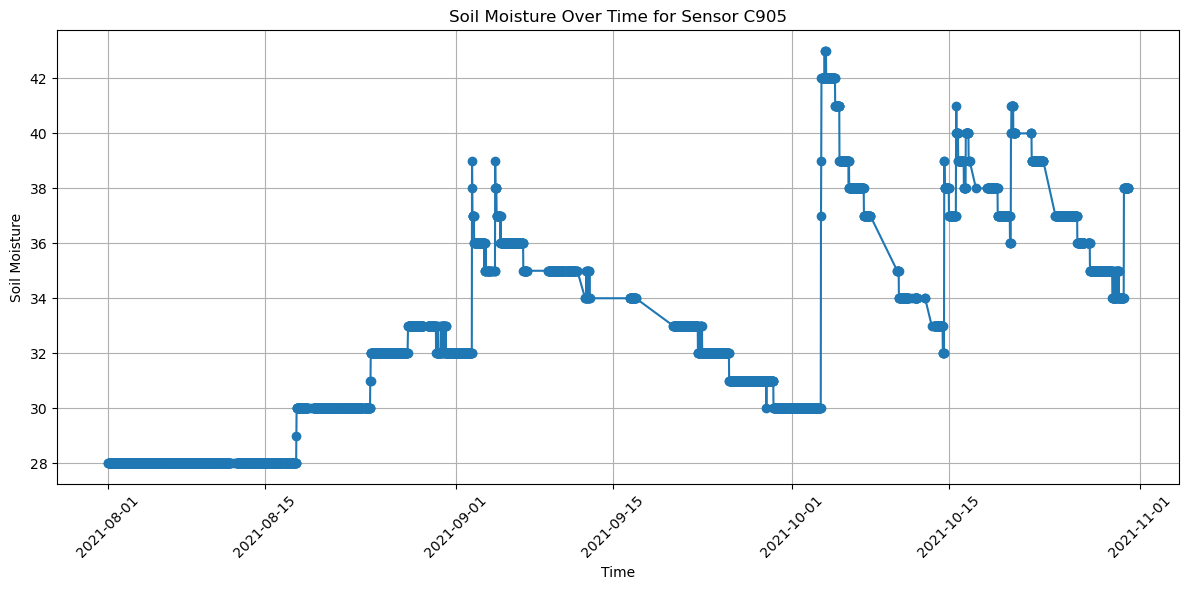


--- Sensor C906 Consistency Analysis ---
Number of spikes detected: 16
Spike timestamps:
75197    2021-08-23 08:21:24
75815    2021-08-24 13:18:50
77884    2021-08-28 07:36:57
78865    2021-08-30 06:32:08
79147    2021-08-30 20:38:40
81916    2021-09-05 04:28:27
81925    2021-09-05 04:53:12
88327    2021-09-20 09:19:27
91034    2021-09-25 06:03:24
92336    2021-09-27 12:51:19
94056    2021-09-30 09:55:52
95750    2021-10-03 13:41:07
98844    2021-10-10 09:39:42
101556   2021-10-15 15:06:42
104476   2021-10-20 12:43:05
109632   2021-10-30 14:11:51
Name: createdAt, dtype: datetime64[ns]


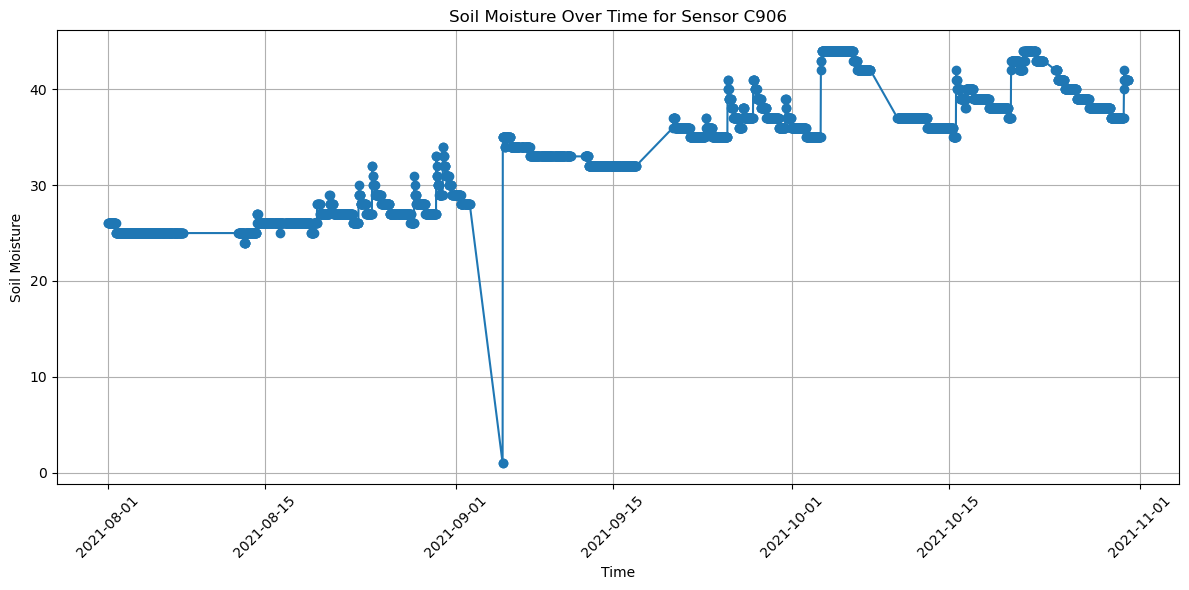


--- Sensor C907 Consistency Analysis ---
Number of spikes detected: 13
Spike timestamps:
69642    2021-08-12 17:02:14
70968    2021-08-15 10:25:58
71416    2021-08-16 09:13:18
73689    2021-08-20 19:47:15
80670    2021-09-02 11:28:32
87980    2021-09-19 00:57:54
95765    2021-10-03 14:23:54
98791    2021-10-10 06:41:19
101566   2021-10-15 15:27:02
104467   2021-10-20 12:17:16
104917   2021-10-21 14:06:48
104924   2021-10-21 14:37:11
104931   2021-10-21 15:07:34
Name: createdAt, dtype: datetime64[ns]


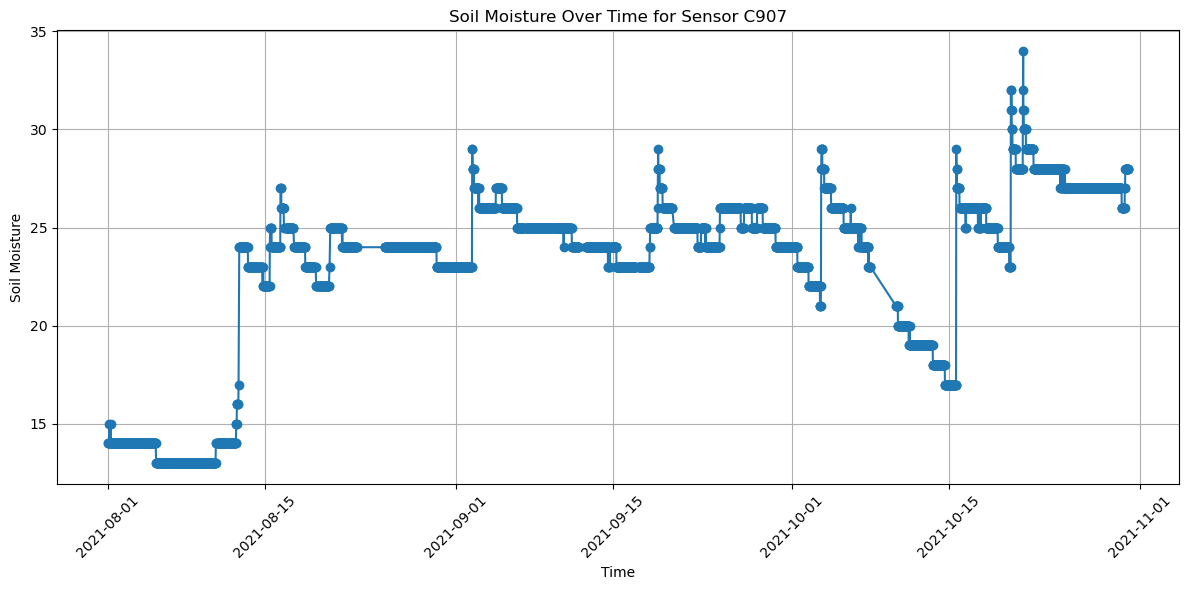


--- Sensor C908 Consistency Analysis ---
Number of spikes detected: 5
Spike timestamps:
95769    2021-10-03 14:35:46
98426    2021-10-08 13:13:02
98429    2021-10-08 13:17:28
105146   2021-10-22 06:48:29
106023   2021-10-24 12:14:53
Name: createdAt, dtype: datetime64[ns]


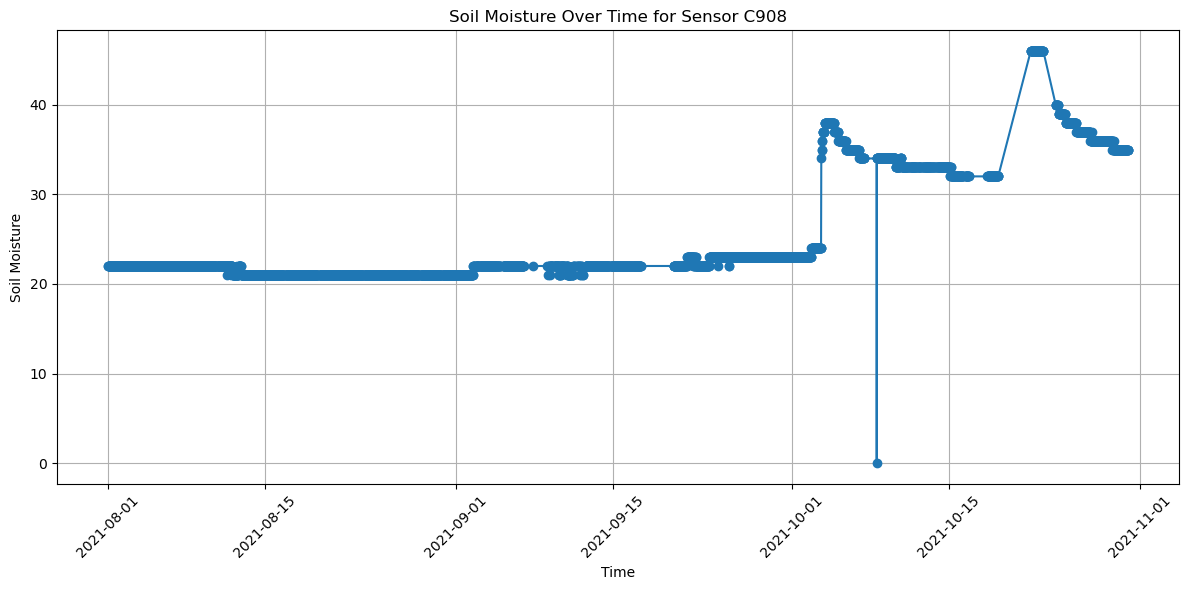


--- Sensor C909 Consistency Analysis ---
Number of spikes detected: 7
Spike timestamps:
70530   2021-08-14 12:22:54
72161   2021-08-17 23:13:50
75688   2021-08-24 07:44:13
75700   2021-08-24 08:15:21
82873   2021-09-07 07:24:07
82881   2021-09-07 07:54:33
95768   2021-10-03 14:32:02
Name: createdAt, dtype: datetime64[ns]


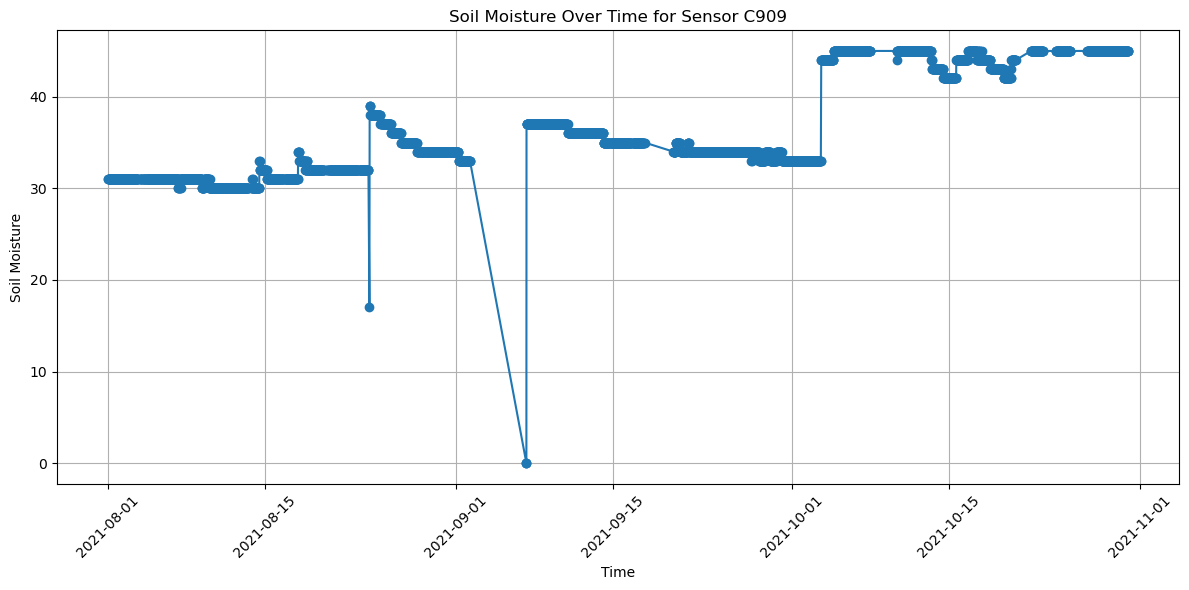


--- Sensor C910 Consistency Analysis ---
Number of spikes detected: 118
Spike timestamps:
68720    2021-08-10 14:05:34
68728    2021-08-10 14:35:49
68901    2021-08-11 01:39:51
68910    2021-08-11 02:10:01
68940    2021-08-11 04:10:40
                 ...        
109208   2021-10-29 22:04:51
109222   2021-10-29 22:35:08
109263   2021-10-30 00:05:58
109445   2021-10-30 07:10:13
109866   2021-10-30 22:52:54
Name: createdAt, Length: 118, dtype: datetime64[ns]


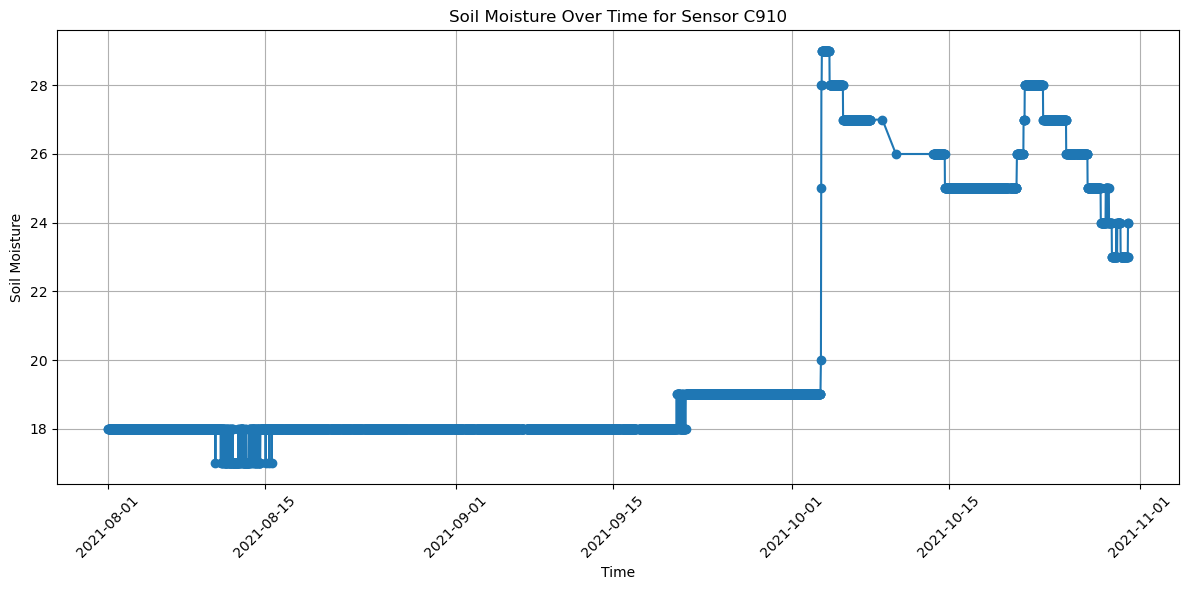


--- Sensor C911 Consistency Analysis ---
Number of spikes detected: 25
Spike timestamps:
66697    2021-08-06 09:31:15
67819    2021-08-08 14:12:51
69611    2021-08-12 15:42:10
69623    2021-08-12 16:12:28
73586    2021-08-20 14:16:46
73658    2021-08-20 17:19:07
76815    2021-08-26 08:50:39
79153    2021-08-30 20:57:44
80057    2021-09-01 09:40:52
80645    2021-09-02 10:22:04
80656    2021-09-02 10:52:17
80666    2021-09-02 11:22:29
80709    2021-09-02 13:23:15
81628    2021-09-04 12:48:07
92363    2021-09-27 14:04:43
95749    2021-10-03 13:39:34
95771    2021-10-03 14:40:00
96009    2021-10-04 02:18:02
98806    2021-10-10 07:42:27
101565   2021-10-15 15:24:05
104475   2021-10-20 12:42:51
104922   2021-10-21 14:32:44
109626   2021-10-30 13:59:16
109639   2021-10-30 14:29:23
109653   2021-10-30 14:59:36
Name: createdAt, dtype: datetime64[ns]


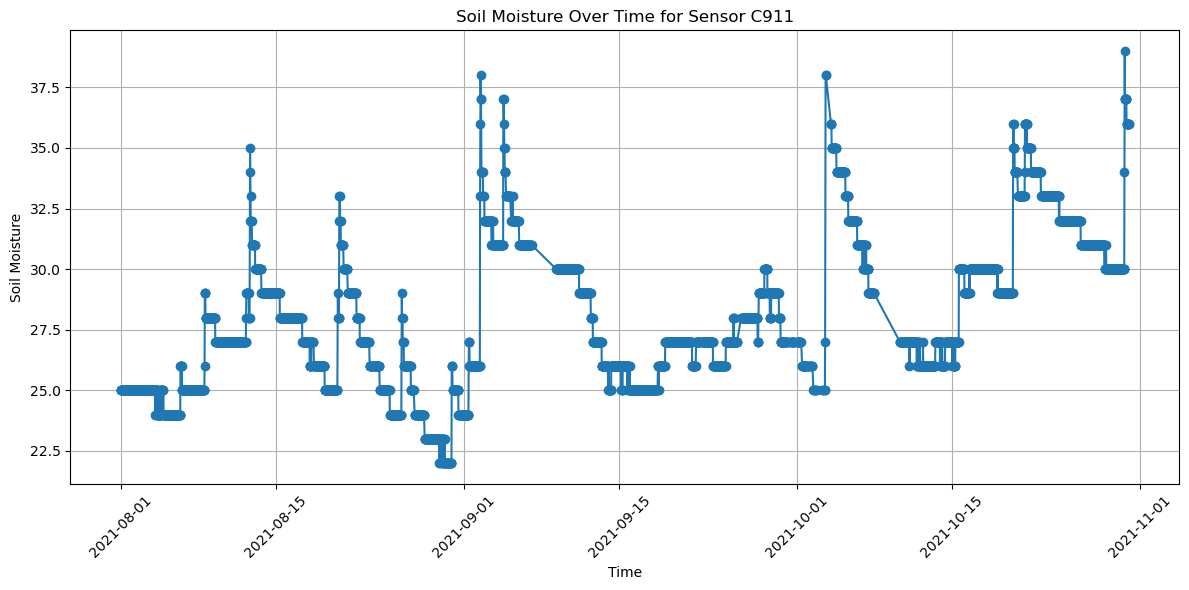


--- Sensor C912 Consistency Analysis ---
Number of spikes detected: 40
Spike timestamps:
87799    2021-09-18 06:23:29
87978    2021-09-19 00:48:11
92073    2021-09-27 02:12:18
92097    2021-09-27 03:13:03
92337    2021-09-27 12:52:39
94107    2021-09-30 12:04:25
95375    2021-10-02 19:59:34
95396    2021-10-02 21:00:28
95438    2021-10-02 23:02:17
95449    2021-10-02 23:32:43
95460    2021-10-03 00:03:12
95504    2021-10-03 02:05:11
95515    2021-10-03 02:35:36
95578    2021-10-03 05:38:47
95588    2021-10-03 06:09:11
95599    2021-10-03 06:39:39
95754    2021-10-03 13:46:31
95770    2021-10-03 14:36:54
96229    2021-10-04 11:55:37
96268    2021-10-04 13:27:10
96282    2021-10-04 13:57:35
96295    2021-10-04 14:28:01
96322    2021-10-04 15:28:52
96335    2021-10-04 15:59:18
96346    2021-10-04 16:29:43
96410    2021-10-04 19:01:40
96436    2021-10-04 20:02:23
96477    2021-10-04 21:34:30
97492    2021-10-06 12:24:21
97533    2021-10-06 13:56:06
100344   2021-10-13 15:11:56
100345   20

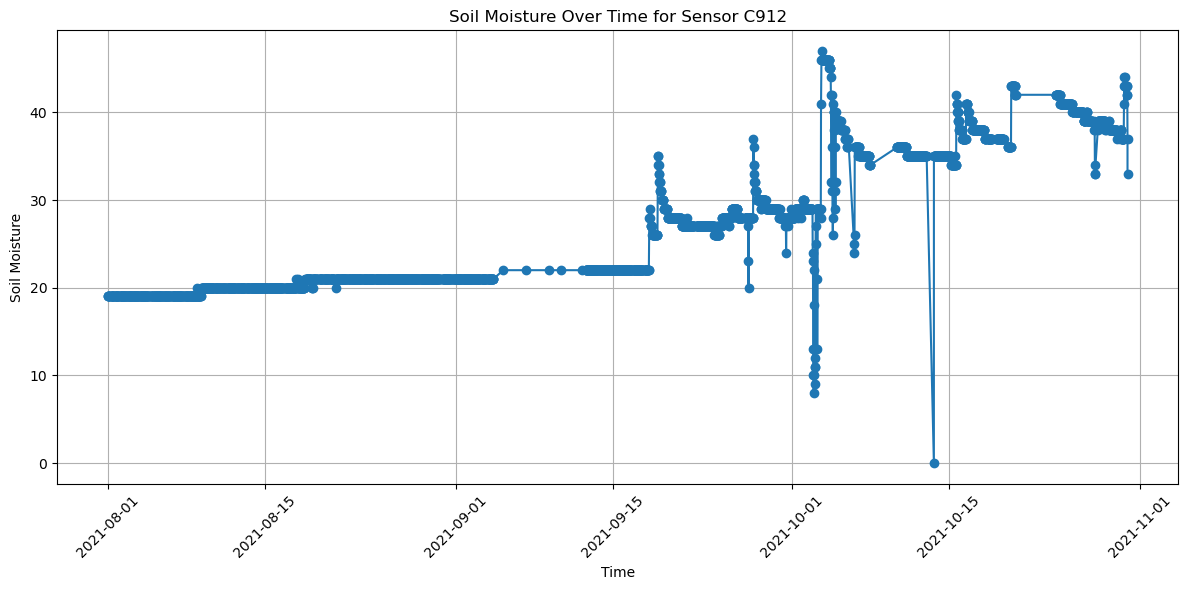


--- Sensor C913 Consistency Analysis ---
Number of spikes detected: 11
Spike timestamps:
69010    2021-08-11 08:10:55
69020    2021-08-11 08:45:15
81229    2021-09-03 16:46:36
81636    2021-09-04 13:07:28
87974    2021-09-19 00:23:44
92342    2021-09-27 13:08:07
95752    2021-10-03 13:42:01
98431    2021-10-08 13:31:01
104486   2021-10-20 13:12:17
106033   2021-10-24 12:37:26
109645   2021-10-30 14:37:43
Name: createdAt, dtype: datetime64[ns]


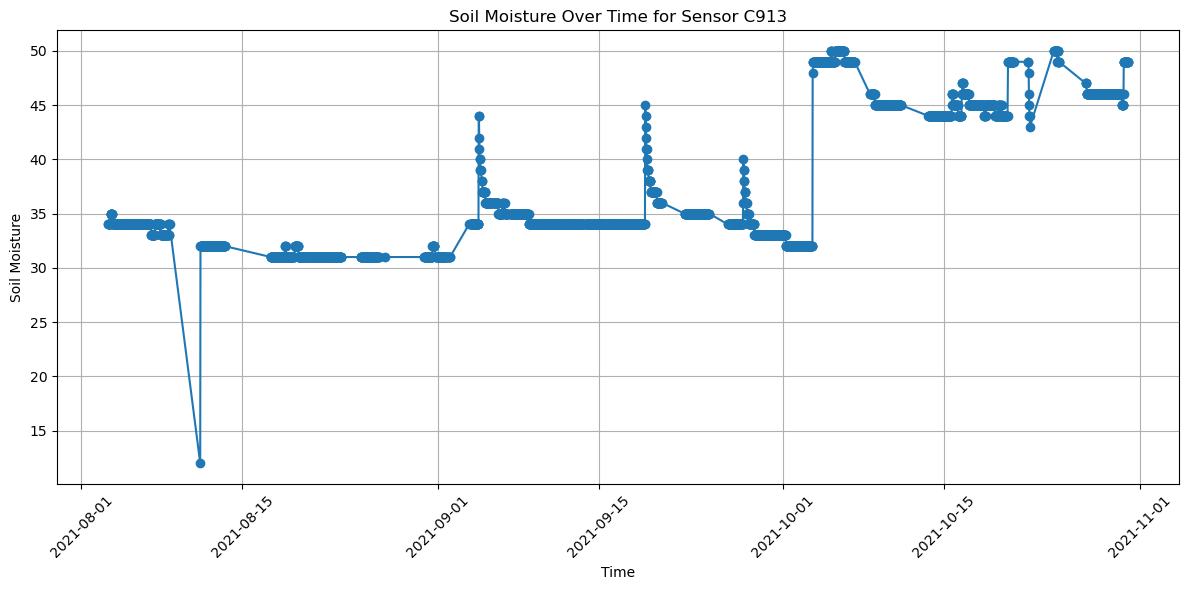


--- Sensor C914 Consistency Analysis ---
Number of spikes detected: 7
Spike timestamps:
71881    2021-08-17 10:42:32
80667    2021-09-02 11:22:55
83773    2021-09-10 00:12:26
84146    2021-09-10 16:27:35
85862    2021-09-14 03:47:44
85883    2021-09-14 04:40:23
101561   2021-10-15 15:13:47
Name: createdAt, dtype: datetime64[ns]


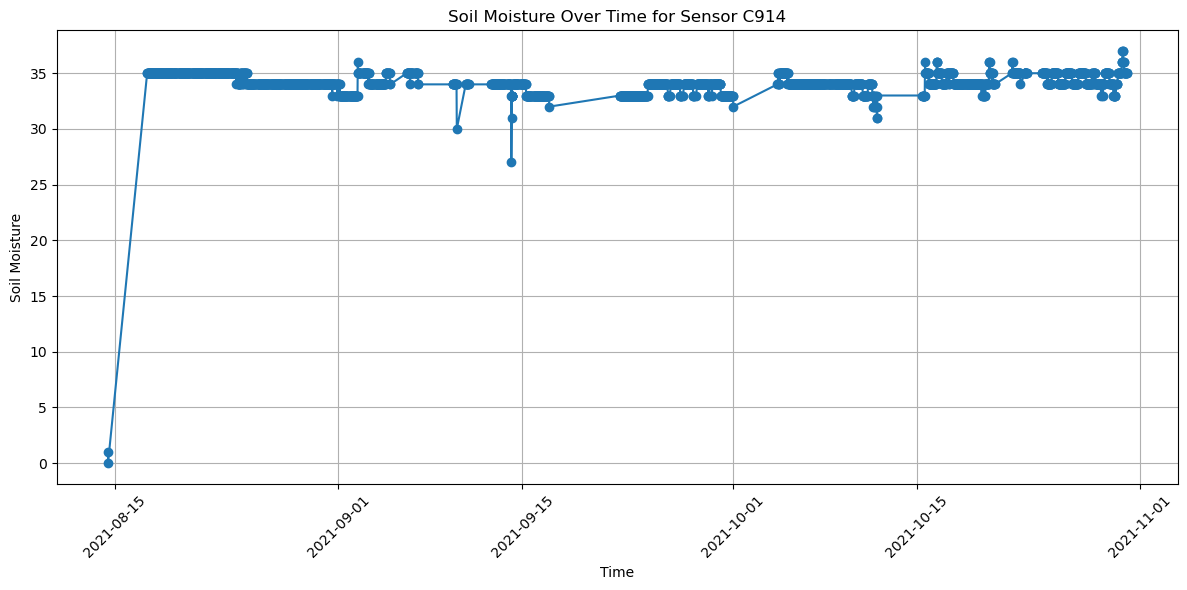

In [29]:
# 1. Group data by sensor_id
grouped = df_combined.groupby('sensor_id')

# 2. Analyze variations for abrupt spikes or sensor failures
def analyze_sensor_consistency(sensor_data, sensor_id):
    """Analyzes sensor data for inconsistencies and plots the data over time."""
    
    # Sort data by time
    sensor_data = sensor_data.sort_values(by='createdAt')
    
    # Calculate the difference between consecutive readings
    sensor_data['soil_moisture_diff'] = sensor_data['soil_moisture'].diff()
    
    # Define a threshold for identifying spikes (e.g., 3 standard deviations from the mean)
    threshold = 3 * sensor_data['soil_moisture_diff'].std()
    
    # Identify spikes
    spikes = sensor_data[abs(sensor_data['soil_moisture_diff']) > threshold]
    
    print(f"\n--- Sensor {sensor_id} Consistency Analysis ---")
    print(f"Number of spikes detected: {len(spikes)}")
    if not spikes.empty:
        print("Spike timestamps:")
        print(spikes['createdAt'])
    
    # Plot soil moisture over time
    plt.figure(figsize=(12, 6))
    plt.plot(sensor_data['createdAt'], sensor_data['soil_moisture'], marker='o', linestyle='-')
    plt.title(f'Soil Moisture Over Time for Sensor {sensor_id}')
    plt.xlabel('Time')
    plt.ylabel('Soil Moisture')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Apply the analysis to each sensor
for sensor_id, sensor_data in grouped:
    analyze_sensor_consistency(sensor_data.copy(), sensor_id)

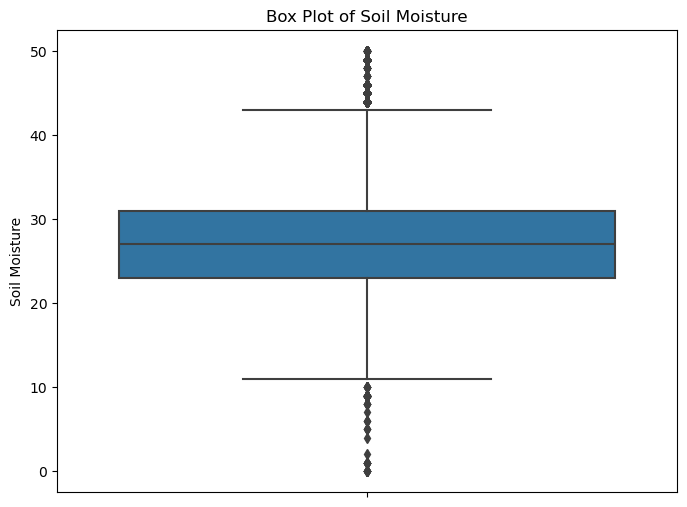

In [31]:
# 1. Outlier Detection (Box plots and Histograms)

# Box plot for soil moisture
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_combined['soil_moisture'])
plt.title('Box Plot of Soil Moisture')
plt.ylabel('Soil Moisture')
plt.show()


Outliers (Black Dots)

Any data points outside 1.5 × IQR from Q1 or Q3 are considered outliers.
High outliers (> 40): Could indicate over-irrigation, sensor error, or heavy rainfall.
Low outliers (< 10): Could indicate drought, soil dryness, or faulty sensors.

C:\Users\robot\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


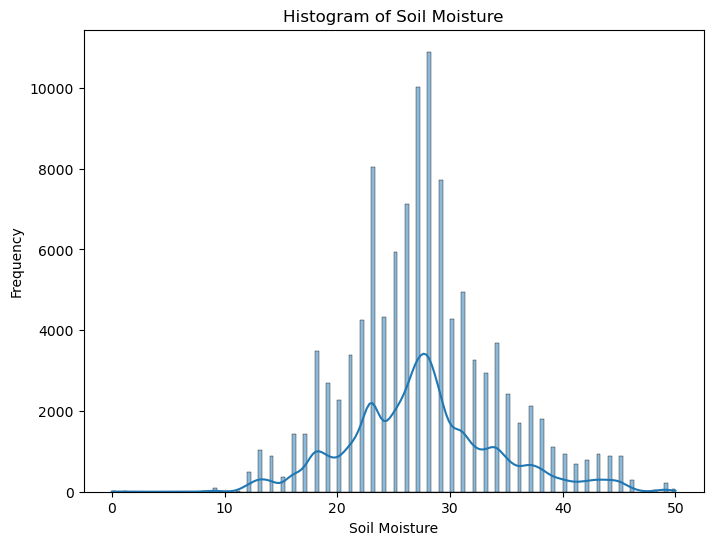

In [32]:
# Histogram for soil moisture
plt.figure(figsize=(8, 6))
sns.histplot(df_combined['soil_moisture'], kde=True)
plt.title('Histogram of Soil Moisture')
plt.xlabel('Soil Moisture')
plt.ylabel('Frequency')
plt.show()

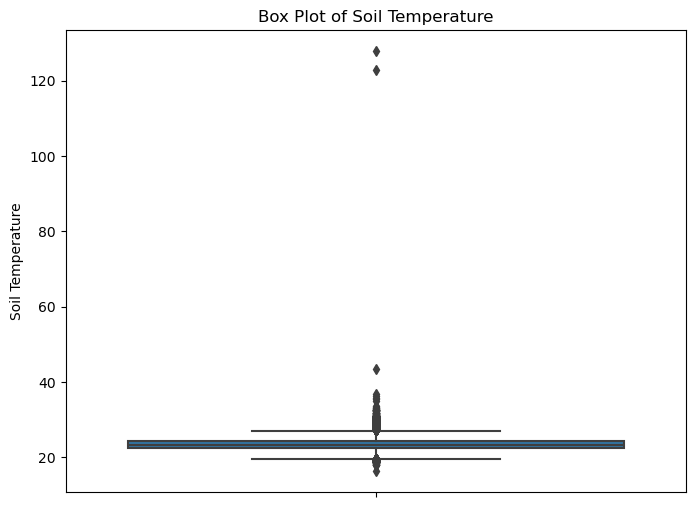

In [33]:
# Box plot for soil temperature
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_combined['soil_temperature'])
plt.title('Box Plot of Soil Temperature')
plt.ylabel('Soil Temperature')
plt.show()

C:\Users\robot\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


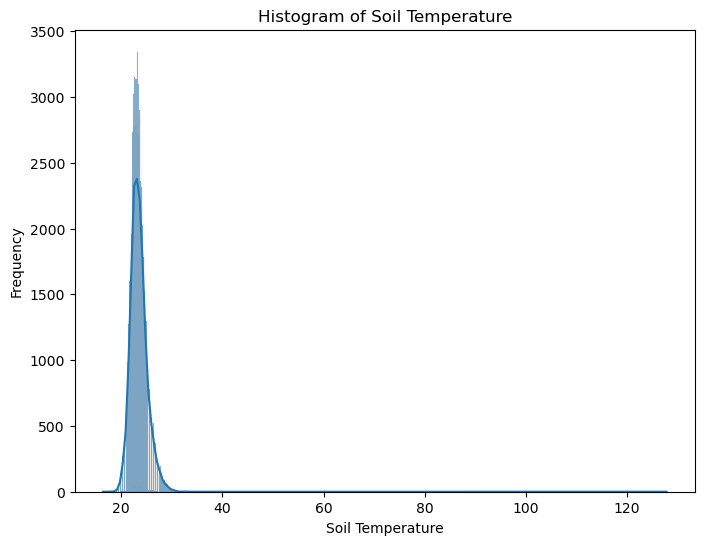

In [34]:
# Histogram for soil temperature
plt.figure(figsize=(8, 6))
sns.histplot(df_combined['soil_temperature'], kde=True)
plt.title('Histogram of Soil Temperature')
plt.xlabel('Soil Temperature')
plt.ylabel('Frequency')
plt.show()

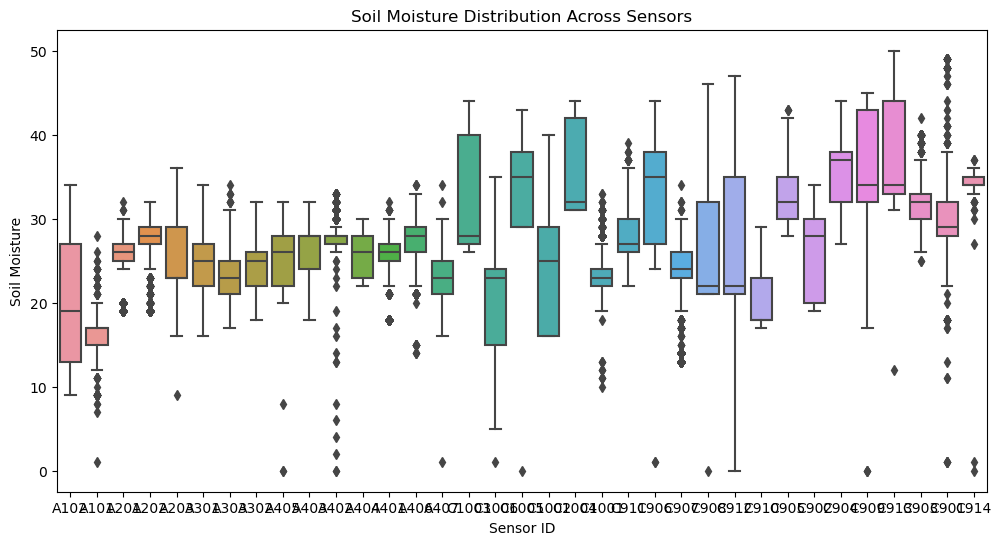

In [35]:
# 2. Soil Moisture Distribution Across Sensors
plt.figure(figsize=(12, 6))
sns.boxplot(x='sensor_id', y='soil_moisture', data=df_combined)
plt.title('Soil Moisture Distribution Across Sensors')
plt.xlabel('Sensor ID')
plt.ylabel('Soil Moisture')
plt.show()

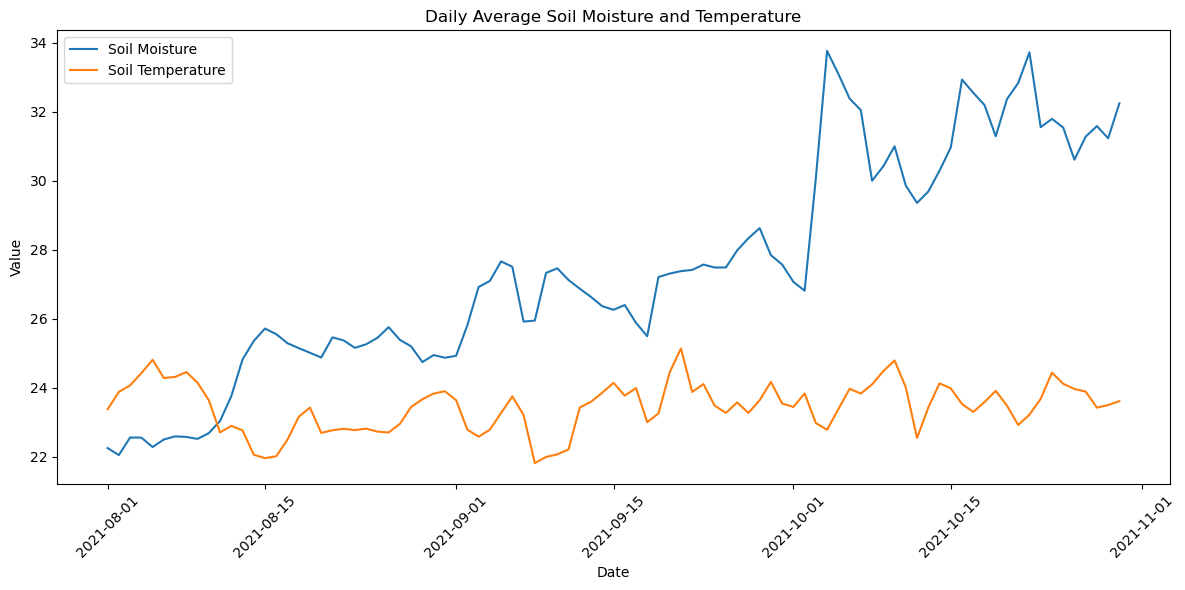

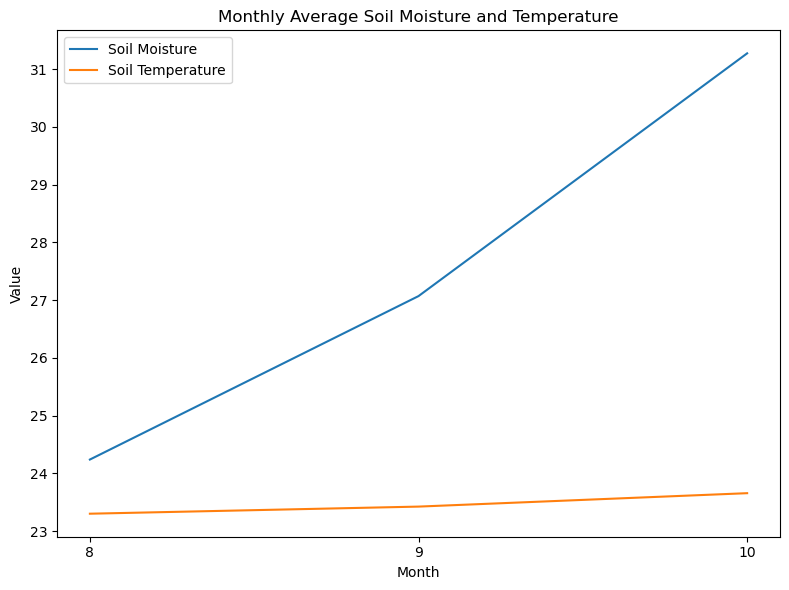

In [36]:
# 3. Daily and Monthly Changes

# Extract daily and monthly data
df_combined['date'] = df_combined['createdAt'].dt.date
df_combined['month'] = df_combined['createdAt'].dt.month

# Calculate daily average soil moisture and temperature
daily_avg = df_combined.groupby('date')[['soil_moisture', 'soil_temperature']].mean()

# Calculate monthly average soil moisture and temperature
monthly_avg = df_combined.groupby('month')[['soil_moisture', 'soil_temperature']].mean()

# Plot daily averages
plt.figure(figsize=(12, 6))
plt.plot(daily_avg.index, daily_avg['soil_moisture'], label='Soil Moisture')
plt.plot(daily_avg.index, daily_avg['soil_temperature'], label='Soil Temperature')
plt.title('Daily Average Soil Moisture and Temperature')
plt.xlabel('Date')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot monthly averages
plt.figure(figsize=(8, 6))
plt.plot(monthly_avg.index, monthly_avg['soil_moisture'], label='Soil Moisture')
plt.plot(monthly_avg.index, monthly_avg['soil_temperature'], label='Soil Temperature')
plt.title('Monthly Average Soil Moisture and Temperature')
plt.xlabel('Month')
plt.ylabel('Value')
plt.xticks(monthly_avg.index)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\robot\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\robot\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


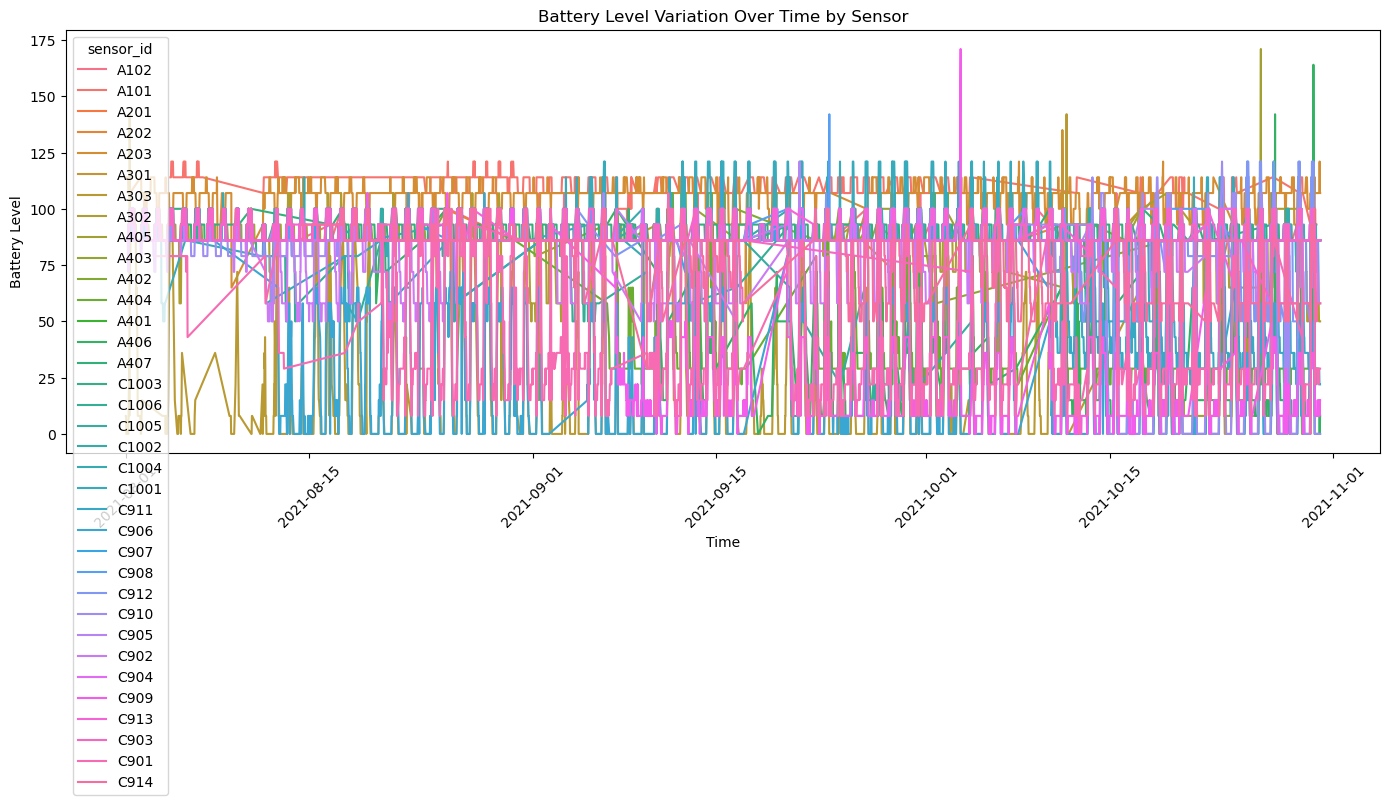


Number of missing soil moisture values when battery is below 20: 0


C:\Users\robot\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\robot\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


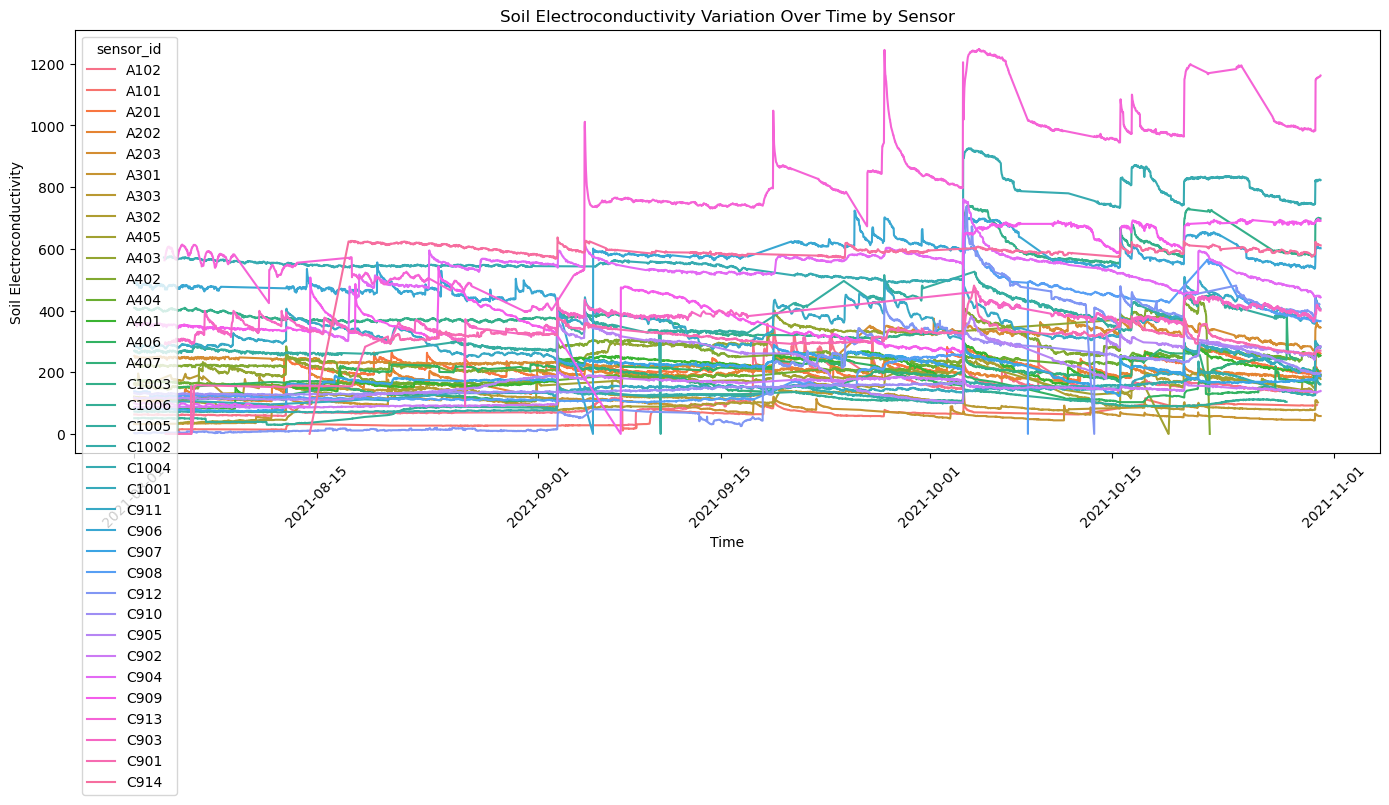

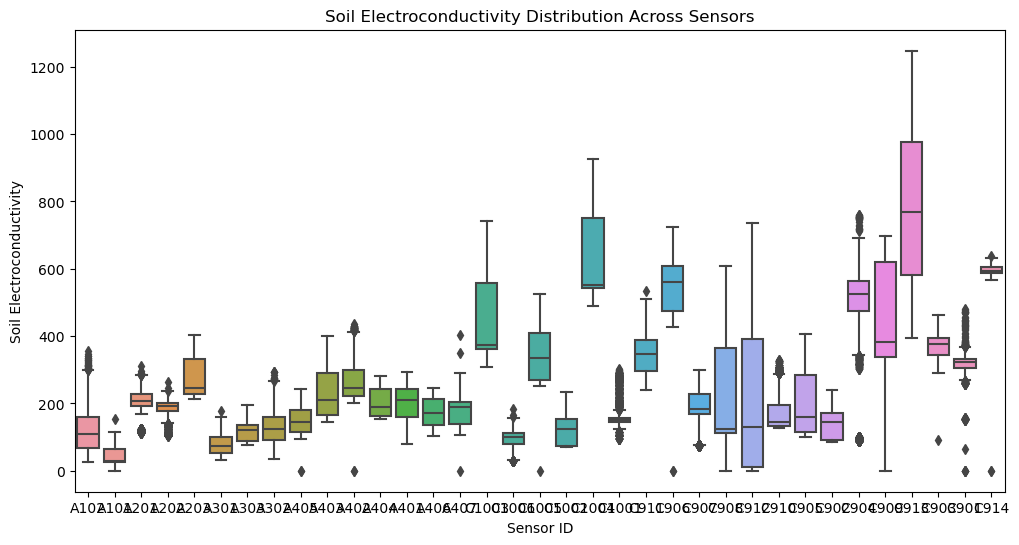


Correlation between soil temperature and soil moisture: -0.11599441887775912


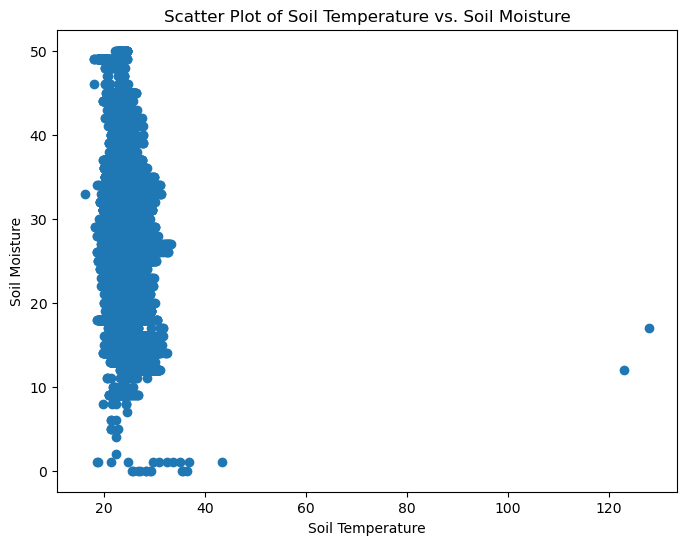

In [41]:
# --- Additional Analysis ---

# 1. Battery Level Variation Over Time

# Plot battery level over time for each sensor
plt.figure(figsize=(14, 7))
sns.lineplot(x='createdAt', y='battery_level', hue='sensor_id', data=df_combined)
plt.title('Battery Level Variation Over Time by Sensor')
plt.xlabel('Time')
plt.ylabel('Battery Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Check for correlation between low battery and missing data (example: soil moisture)
# Define a threshold for low battery (e.g., below 20) - adjust as needed
low_battery_threshold = 20
low_battery_data = df_combined[df_combined['battery_level'] < low_battery_threshold]
missing_soil_moisture_with_low_battery = low_battery_data['soil_moisture'].isnull().sum()

print(f"\nNumber of missing soil moisture values when battery is below {low_battery_threshold}: {missing_soil_moisture_with_low_battery}")

# 2. Soil Electroconductivity Changes

# Plot soil electroconductivity over time for each sensor
plt.figure(figsize=(14, 7))
sns.lineplot(x='createdAt', y='soil_electrocoductivity', hue='sensor_id', data=df_combined)
plt.title('Soil Electroconductivity Variation Over Time by Sensor')
plt.xlabel('Time')
plt.ylabel('Soil Electroconductivity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot soil electroconductivity distribution across sensors
plt.figure(figsize=(12, 6))
sns.boxplot(x='sensor_id', y='soil_electrocoductivity', data=df_combined)
plt.title('Soil Electroconductivity Distribution Across Sensors')
plt.xlabel('Sensor ID')
plt.ylabel('Soil Electroconductivity')
plt.show()

# 3. Correlation Between Soil Temperature and Soil Moisture
correlation = df_combined['soil_temperature'].corr(df_combined['soil_moisture'])
print(f"\nCorrelation between soil temperature and soil moisture: {correlation}")

# Scatter plot to visualize the correlation
plt.figure(figsize=(8, 6))
plt.scatter(df_combined['soil_temperature'], df_combined['soil_moisture'])
plt.title('Scatter Plot of Soil Temperature vs. Soil Moisture')
plt.xlabel('Soil Temperature')
plt.ylabel('Soil Moisture')
plt.show()

In [68]:
file_paths = [
    os.path.join(data_dir, 'August-October-2021-sectionA1-data.csv'),
    os.path.join(data_dir, 'August-October-2021-sectionA2-data.csv'),
    os.path.join(data_dir, 'August-October-2021-sectionA3-data.csv'),
    os.path.join(data_dir, 'August-October-2021-sectionA4-data.csv'),
    os.path.join(data_dir, 'August-October-2021-sectionC10-data.csv'),
    os.path.join(data_dir, 'August-October-2021-sectionC9-data.csv')
]

In [69]:
# Read and merge all CSV files
dfs = [pd.read_csv(file) for file in file_paths]  # Read all CSVs

# Concatenate all dataframes
merged_df = pd.concat(dfs, ignore_index=True)  

In [70]:
# Save merged dataset
output_path = os.path.join(data_dir, "farmStream.csv")
merged_df.to_csv(output_path, index=False)

print(f"Combined CSV saved to: {output_path}")

Combined CSV saved to: C:\Users\robot\Vault\Spring24\CAPSTONE\Lab2\farmStream.csv


In [78]:
farmData_path = os.path.join(data_dir, 'farmStream.csv')

farmStream_df = pd.read_csv(farmData_path)

In [79]:
farmData = len(farmStream_df)
print(f"\nTotal DataStream over 2021: {farmData}")


Total DataStream over 2021: 109894


In [82]:
# farmStream_df['createdAt'] = pd.to_datetime(farmStream_df['createdAt'])
# farmStream_df.set_index('createdAt', inplace=True)

farmStream_df["createdAt"] = pd.to_datetime(farmStream_df["createdAt"], format="%Y-%m-%d %H:%M:%S")


In [83]:
farmStream_df = farmStream_df.select_dtypes(include=['number'])
# Exclude non-numeric columns
numeric_cols = farmStream_df.select_dtypes(include=['number']).columns

In [ ]:
# daily_trend = farmStream_df.resample('D').mean()  # Aggregating data by day
daily_trend.plot(title="Daily Trend", figsize=(12, 6))

In [52]:
print(farmStream_df.dtypes)

df_numeric = df.select_dtypes(include=['number'])


id                           int64
soil_moisture                int64
soil_temperature           float64
soil_electrocoductivity      int64
battery_level                int64
sensor_id                   object
owner                       object
dtype: object


In [26]:
monthly_trend = farmStream_df.drop(columns=["id"])
monthly_trend.groupby("createdAt").mean()

# monthly_trend = farmStream_df.resample('M').mean()  # Aggregating data by month


,soil_moisture,soil_temperature,soil_electrocoductivity,battery_level
createdAt,,,,
2021-08-01 00:00:43,23.0,22.20,121.0,86.0
2021-08-01 00:02:06,26.0,21.00,164.0,86.0
2021-08-01 00:02:14,25.0,20.80,286.0,86.0
2021-08-01 00:06:27,26.0,22.40,490.0,86.0
2021-08-01 00:08:56,27.0,20.70,228.0,86.0
...,...,...,...,...
2021-10-30 23:52:19,44.0,23.40,823.0,86.0
2021-10-30 23:53:30,35.0,23.20,443.0,86.0
2021-10-30 23:55:00,30.0,23.50,58.0,86.0


In [63]:
print(daily_trend.dtypes)

id                         float64
soil_moisture              float64
soil_temperature           float64
soil_electrocoductivity    float64
battery_level              float64
dtype: object
